# Project 2: Joint Detection of AI-Generated Images and Post-Processing Alterations
#
Notebook structure: Imports, Globals, Utils, Data, Network, Train, Evaluation.

## Imports

### Install the packages
Local installations.

In [1]:
# %pip install -q numpy pandas matplotlib seaborn scikit-learn Pillow torch transformers peft

### Import everything we use
Import all libraries.

In [2]:
# standard library
import os
import re
import copy
import random
from pathlib import Path
from dataclasses import dataclass

# data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
Image.MAX_IMAGE_PIXELS = None   # allow very large images
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from transformers import AutoModel, AutoImageProcessor
from huggingface_hub import login
from peft import LoraConfig, get_peft_model

## Globals

### All the settings in one place
Every value we might want to change lives here, so we never have to hunt for it later.

In [3]:
# Reproducibility.
SEED = 42

# Dataset path.
if Path("/kaggle/input").exists():
    DATA_ROOT = "/kaggle/input/datasets/jannip/rrdataset/RRDataset_final"
else:
    DATA_ROOT = "./data/RRDataset_final"

# Folder names to labels.
# Task A (authenticity): is the image real or AI-generated?
REALFAKE_ID   = {"real": 0, "ai": 1}     # the number the model will predict
REALFAKE_NAME = {0: "real", 1: "fake"}   # a readable name for plots and tables

# Task B (transformation): what post-processing was applied?
TRANSFORM_FOLDERS = ["original", "transfer", "redigital"]   # the folder names on disk
TRANSFORM_ID      = {"original": 0, "transfer": 1, "redigital": 2}
TRANSFORM_NAME    = {"original": "original", "transfer": "transmitted", "redigital": "redigitized"}
TRANSFORM_LABELS  = [TRANSFORM_NAME[k] for k in TRANSFORM_FOLDERS]   # display names in class order 0,1,2

CLASS_FOLDERS = ["real", "ai"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

# Dataset values.
SUBSET_PER_CLASS = 8000              # scenes per class to keep (each scene = 3 images)
SPLIT_RATIOS = (0.70, 0.15, 0.15)    # train / validation / test, measured in scenes

# Where to save outputs.
OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
INDEX_CSV = OUT_DIR / "rrdataset_index.csv"

# Backbone.
BACKBONE_ID = "facebook/dinov3-vitb16-pretrain-lvd1689m"   # DINOv3 (gated)
FEATURE_DIM = 768
FEATS_NPY   = OUT_DIR / "feats.npy"

# FFT branch: a small frequency descriptor concatenated to the CLS features
# Every model is trained twice: once on CLS only, once on CLS + FFT.
FFT_SIZE      = 256        # images are grayscaled and resized to this before the FFT
FFT_BINS      = 128
FFT_FEATS_NPY = OUT_DIR / "fft_feats.npy"
FFT_MEAN      = None 
FFT_STD       = None

# HuggingFace token for the gated DINOv3 download.
# Empty for Kaggle (use Add-ons -> Secrets), filled in for local runs.
HF_TOKEN = ""

# Head and training settings.
HIDDEN_DIM = 256
DROPOUT    = 0.3
EPOCHS     = 50
PATIENCE   = 8          # early stopping: stop if val does not improve for this many epochs
LR         = 1e-3
BATCH_SIZE = 256

# LoRA settings: instead of freezing the backbone, we let it adapt a little.
LORA_R      = 8
LORA_ALPHA  = 16
LORA_EPOCHS = 3
LORA_LR     = 1e-4
LORA_BATCH  = 64
LORA_WEIGHTS = OUT_DIR / "lora_model.pt"   # cache the trained LoRA so we do not retrain each time
LORA_FFT_WEIGHTS = OUT_DIR / "lora_fft_model.pt"   # cache for the CLS + FFT LoRA model
RETRAIN_LORA = True   # set True to discard the cached parameters and retrain.

## Utils
All the support functions and small helper classes, grouped by the section they serve.

### General helpers

#### Make the run repeatable
We fix every random seed so two runs give the same numbers and our results are trustworthy.

In [4]:
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

#### Pick the device
We use the GPU if there is one, otherwise the CPU.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)

Using device: cuda
GPU: Tesla T4 | CUDA 12.8


### Data helpers

#### Read the labels from a file name
The three versions of one scene share a name apart from a prefix. Strip the prefix to get one
id that links them, so later we can keep all three versions of a scene in the same split.

In [6]:
def get_base_id(filename):
    """Turn a file name into a scene id shared by its 3 transform versions.

        Culture_&_Religion_000001.png            -> Culture_&_Religion_000001
        transfer_Culture_&_Religion_000001.jpg   -> Culture_&_Religion_000001
        redigital_real_000001.jpg                -> real_000001
    """
    name_without_extension = os.path.splitext(filename)[0]
    return re.sub(r"^(transfer_|redigital_)", "", name_without_extension)


def get_scenario(base_id, is_fake):
    """AI file names start with a scenario (e.g. 'War_&_Conflict_Scenes_000012').
    Real images are just 'real_000012', so we label them all 'real'."""
    if not is_fake:
        return "real"
    scenario = re.sub(r"_\d+$", "", base_id)   # drop the trailing number
    return scenario.replace("__", "_and_")     # the __ is where the '&' used to be

#### Bar chart of category counts
A small helper that draws a labelled bar chart. We use it to check the class balance.

In [7]:
def bar_counts(values, title, ax):
    counts = values.value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("number of images")
    for i, n in enumerate(counts.values):
        ax.text(i, n, str(n), ha="center", va="bottom", fontsize=9)

#### One bundle of features, labels and split masks
`Splits` groups everything a feature-based model needs - the feature matrix, both task labels and
the train/val/test row masks - plus a `tag` ("cls" or "fft") used in filenames and plot titles.
`make_splits` builds one from a feature array and the table. We build two: one for the CLS
features and one for the CLS + FFT features, so the rest of the code can treat them the same way.

In [8]:
@dataclass
class Splits:
    feats: torch.Tensor       # (N, in_dim) feature matrix
    y_a: torch.Tensor         # real/fake label
    y_b: torch.Tensor         # transformation label
    is_train: torch.Tensor    # boolean row masks
    is_val: torch.Tensor
    is_test: torch.Tensor
    tag: str                  # "cls" or "fft"

    @property
    def in_dim(self):
        return self.feats.shape[1]


def make_splits(feats, subset, tag):
    split_column = subset["split"].values
    return Splits(
        feats=torch.tensor(feats, dtype=torch.float32),
        y_a=torch.tensor(subset["realfake"].values, dtype=torch.long),
        y_b=torch.tensor(subset["transform"].values, dtype=torch.long),
        is_train=torch.tensor(split_column == "train"),
        is_val=torch.tensor(split_column == "val"),
        is_test=torch.tensor(split_column == "test"),
        tag=tag,
    )

#### One bundle of trained models for a feature set
`Trained` collects everything produced for one `Splits`: the grid-search tables and best config,
the two baseline heads (with their training curves), the best joint model from the sweep (with its
sweep tables), and the LoRA model. The training loop fills one `Trained` per feature set, so the
CLS and CLS + FFT results never need parallel `_fft` variable names.

In [9]:
@dataclass
class Trained:
    data: Splits
    grid_a: pd.DataFrame = None
    grid_b: pd.DataFrame = None
    grid_joint: pd.DataFrame = None
    best: dict = None
    head_a: nn.Module = None
    head_b: nn.Module = None
    hist_a: dict = None
    hist_b: dict = None
    joint: nn.Module = None
    ratio: float = None
    bottleneck: pd.DataFrame = None
    sweep: pd.DataFrame = None
    hidden_sizes: list = None
    lora: nn.Module = None

### Network helpers

#### Dataset that reads one image
Opens an image and turns it into the tensor the backbone expects. The DataLoader uses many of
these in parallel.

In [10]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert("RGB")
        return processor(images=image, return_tensors="pt").pixel_values[0]

#### Run the backbone over many images
Sends batches of images through the frozen backbone and keeps the CLS vector of each one. We
call this once and save the result, so every later experiment can reuse the saved numbers.

In [11]:
@torch.no_grad()
def extract_features(paths, batch_size=64, num_workers=4):
    # shuffle=False keeps the output rows in the same order as `paths` (and the table).
    loader = DataLoader(ImageDataset(paths), batch_size=batch_size,
                        num_workers=num_workers, pin_memory=True)
    all_feats, done = [], 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        cls = backbone(pixel_values=batch).last_hidden_state[:, 0]   # CLS token, one row per image
        all_feats.append(cls.cpu())
        done += len(batch)
        print(f"  {done} / {len(paths)} images", end="\r")
    return torch.cat(all_feats).numpy()

#### A small FFT descriptor of an image
The frequency view of one image: grayscale, resize to a fixed size (so spectra are comparable
across images), take the 2D FFT, then average the log-power spectrum over rings of equal radius.
The result is a short fixed-length vector (the azimuthally averaged spectrum) that captures the
periodic compression / resampling artifacts the CLS token tends to throw away.

In [12]:
def radial_spectrum(image, size=FFT_SIZE, n_bins=FFT_BINS):
    gray = image.convert("L").resize((size, size), Image.BILINEAR)
    arr = np.asarray(gray, dtype=np.float32) / 255.0
    arr = arr - arr.mean()                                    # drop the DC term
    power = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(arr))) ** 2)
    center = size // 2
    y, x = np.indices((size, size))
    radius = np.sqrt((x - center) ** 2 + (y - center) ** 2).astype(int)
    sums = np.bincount(radius.ravel(), power.ravel())
    counts = np.bincount(radius.ravel())
    profile = sums / np.maximum(counts, 1)                    # azimuthal average, one value per ring
    return profile[:n_bins].astype(np.float32)


def extract_fft_features(paths):
    feats = np.zeros((len(paths), FFT_BINS), dtype=np.float32)
    for i, path in enumerate(paths):
        feats[i] = radial_spectrum(Image.open(path).convert("RGB"))
        if (i + 1) % 1000 == 0:
            print(f"  {i + 1} / {len(paths)} images", end="\r")
    return feats

#### Dataset that also returns the labels
Like the one above, but it also gives back the two labels. The LoRA model trains on images, so
it needs the answers during training, not only the pixels.

In [13]:
class LabeledImageDataset(torch.utils.data.Dataset):
    def __init__(self, frame, use_fft=False):
        self.paths = frame["path"].tolist()
        self.y_a = frame["realfake"].tolist()
        self.y_b = frame["transform"].tolist()
        self.use_fft = use_fft

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt").pixel_values[0]
        if self.use_fft:
            fft = torch.tensor((radial_spectrum(image) - FFT_MEAN) / FFT_STD, dtype=torch.float32)
        else:
            fft = torch.zeros(0, dtype=torch.float32)        # empty -> the model skips the concat
        return pixel_values, fft, self.y_a[i], self.y_b[i]

### Train helpers

#### Accuracy of a single-task head
Given a head and some features, returns the fraction of correct predictions. We use it during
training to watch the validation score.

In [14]:
def accuracy(head, X, y):
    head.eval()
    with torch.no_grad():
        preds = head(X.to(device)).argmax(1).cpu()
    return (preds == y).float().mean().item()

#### Accuracy of the joint model
The joint model returns two outputs at once, so this returns the accuracy of both tasks together.

In [15]:
def joint_accuracy(model, data, mask):
    model.eval()
    with torch.no_grad():
        out_a, out_b = model(data.feats[mask].to(device))
    acc_a = (out_a.argmax(1).cpu() == data.y_a[mask]).float().mean().item()
    acc_b = (out_b.argmax(1).cpu() == data.y_b[mask]).float().mean().item()
    return acc_a, acc_b

#### Draw the training curves
Plots the loss going down and the accuracy going up across epochs, so we can spot overfitting.

In [16]:
def plot_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"])
    axes[0].set_title(f"{title}: training loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

### Evaluation helpers

#### Predictions of an image model
Runs an image-based model (the LoRA one) over a set of rows and returns the predicted classes
of both tasks.

In [17]:
@torch.no_grad()
def predict_images(model, frame, use_fft=False, batch_size=LORA_BATCH):
    model.eval()
    use_amp = (device.type == "cuda")
    loader = DataLoader(LabeledImageDataset(frame, use_fft=use_fft), batch_size=batch_size,
                        num_workers=4, pin_memory=True)
    preds_a, preds_b = [], []
    for px, fft, ya, yb in loader:
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            out_a, out_b = model(px.to(device), fft.to(device))
        preds_a.append(out_a.argmax(1).cpu())
        preds_b.append(out_b.argmax(1).cpu())
    return torch.cat(preds_a), torch.cat(preds_b)

#### One prediction interface for every model
`Preds` holds a model's test predictions: the real/fake class `a`, the transformation class `b`,
and `proba_fake` (P(fake), used for the AUC when available). `baseline_preds` / `joint_preds` /
`lora_preds` each turn one trained model into a `Preds`, so the evaluation can score any model the
same way regardless of whether it reads cached features or runs through the backbone.

In [18]:
@dataclass
class Preds:
    a: torch.Tensor           # predicted real/fake
    b: torch.Tensor           # predicted transformation
    proba_fake: object = None  # P(fake) for the AUC, when available

def baseline_preds(head_a, head_b, data):
    with torch.no_grad():
        logits_a = head_a(data.feats[data.is_test].to(device)).cpu()
        pred_b = head_b(data.feats[data.is_test].to(device)).argmax(1).cpu()
    return Preds(a=logits_a.argmax(1), b=pred_b, proba_fake=logits_a.softmax(1)[:, 1].numpy())

def joint_preds(model, data):
    model.eval()
    with torch.no_grad():
        out_a, out_b = model(data.feats[data.is_test].to(device))
    out_a = out_a.cpu()
    return Preds(a=out_a.argmax(1), b=out_b.argmax(1).cpu(), proba_fake=out_a.softmax(1)[:, 1].numpy())

def lora_preds(model, data):
    frame = subset[subset["split"] == "test"]
    pred_a, pred_b = predict_images(model, frame, use_fft=(data.tag == "fft"))
    return Preds(a=pred_a, b=pred_b)

#### Accuracy inside one class
The share of correct predictions inside a single class, so we can report real accuracy and fake
accuracy separately.

In [19]:
def class_accuracy(y_true, y_pred, cls):
    mask = y_true == cls
    return (y_pred[mask] == cls).float().mean().item()

#### Draw a confusion matrix
Shows, for each true class, how often each class was predicted. We use it for every model so we
can compare their mistakes side by side.

In [20]:
def plot_confusion(y_true, y_pred, names, title):
    cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(len(names))))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

#### Precision, recall and F1 table
Accuracy alone can hide a model that ignores one class, so we also report precision, recall and
F1 for each class (plus the averages). We use sklearn's classification_report and show it as a
small table.

In [21]:
def metrics_table(y_true, y_pred, names):
    report = classification_report(y_true.numpy(), y_pred.numpy(),
                                   labels=list(range(len(names))), target_names=names,
                                   output_dict=True, zero_division=0)
    return pd.DataFrame(report).T.round(3)   # rows = classes + averages, cols = precision/recall/f1

#### Score one model
One model's full test report, reused for every model (and its FFT version): Task A / Task B
accuracy (plus real- and fake-accuracy and AUC), the two confusion matrices, and the two
precision/recall/F1 tables. Returns the two accuracies so they can be collected for comparisons.

In [22]:
def report_scores(true_a, pred_a, true_b, pred_b, title, proba_fake=None):
    acc_a = (pred_a == true_a).float().mean().item()
    acc_b = (pred_b == true_b).float().mean().item()
    print(f"{title} - Task A (real vs fake)")
    print(f"  accuracy      : {acc_a:.3f}")
    print(f"  real accuracy : {class_accuracy(true_a, pred_a, 0):.3f}")
    print(f"  fake accuracy : {class_accuracy(true_a, pred_a, 1):.3f}")
    if proba_fake is not None:
        print(f"  AUC           : {roc_auc_score(true_a.numpy(), proba_fake):.3f}")
    print(f"{title} - Task B (transformation)")
    print(f"  accuracy      : {acc_b:.3f}")
    plot_confusion(true_a, pred_a, [REALFAKE_NAME[0], REALFAKE_NAME[1]], f"{title} - Task A confusion matrix")
    plot_confusion(true_b, pred_b, TRANSFORM_LABELS, f"{title} - Task B confusion matrix")
    print(f"{title} - Task A precision / recall / F1:")
    display(metrics_table(true_a, pred_a, [REALFAKE_NAME[0], REALFAKE_NAME[1]]))
    print(f"{title} - Task B precision / recall / F1:")
    display(metrics_table(true_b, pred_b, TRANSFORM_LABELS))
    return acc_a, acc_b

#### Real and fake accuracy per transformation
Splits the real/fake accuracy by transformation and by class. This table is what answers the
core question of the project: do real and fake images react differently to post-processing?

In [23]:
def per_transform_breakdown(true_a, pred_a, true_b):
    """Real-acc and fake-acc for each transformation category, on the test set."""
    table = {}
    for t_id, t_key in enumerate(TRANSFORM_FOLDERS):       # 0 original / 1 transfer / 2 redigital
        col = {}
        for cls in (0, 1):                                  # 0 = real, 1 = fake
            mask = (true_a == cls) & (true_b == t_id)
            col[REALFAKE_NAME[cls]] = (pred_a[mask] == cls).float().mean().item()
        table[TRANSFORM_NAME[t_key]] = col
    return pd.DataFrame(table).round(3)                     # rows = real/fake, cols = transforms

#### Transformation accuracy per class
The mirror of the table above: same layout (rows = real/fake, cols = transformation), but the
value is the transformation classifier's accuracy instead of the real/fake one. It asks the
reverse question: is the post-processing easier to recognise on real images or on AI ones?

In [24]:
def per_class_breakdown(true_a, true_b, pred_b):
    """Transformation accuracy for each (class, transformation) cell, on the test set."""
    table = {}
    for t_id, t_key in enumerate(TRANSFORM_FOLDERS):       # 0 original / 1 transfer / 2 redigital
        col = {}
        for cls in (0, 1):                                  # 0 = real, 1 = fake
            mask = (true_a == cls) & (true_b == t_id)
            col[REALFAKE_NAME[cls]] = (pred_b[mask] == t_id).float().mean().item()
        table[TRANSFORM_NAME[t_key]] = col
    return pd.DataFrame(table).round(3)                     # rows = real/fake, cols = transforms

#### One grouped-bar primitive
All the bar comparisons below (per transformation, per class, degradation, per scenario) are the
same grouped bar chart with different labels, so we draw them through one helper. It plots a table
on a given axis: the index becomes the x groups and the columns become the bars in each group.

In [25]:
def grouped_bar(ax, df, title, ylabel, ylim=(0, 1), zero_line=False, legend_title="", rotation=0, xlabel=None):
    df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(title=legend_title)

#### Draw the per-transformation breakdown
A grouped bar chart of the table above: one group per transformation, with one bar for real and
one for fake, so the gap between them is easy to read.

In [26]:
def plot_breakdown(df, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, df.T, title, "test accuracy", legend_title="class")   # x = transforms, bars = real/fake
    plt.tight_layout()
    plt.show()

#### Compare all models per transformation
Puts every model on one figure: real accuracy on the left, fake accuracy on the right, with one
bar per model inside each transformation, so we can read off which model wins where.

In [27]:
def plot_breakdown_comparison(breakdowns):
    models = list(breakdowns.keys())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, cls in zip(axes, [REALFAKE_NAME[0], REALFAKE_NAME[1]]):
        data = pd.DataFrame({m: breakdowns[m].loc[cls] for m in models})   # rows = transforms, cols = models
        grouped_bar(ax, data, f"{cls} accuracy per transformation", "test accuracy",
                    legend_title="model", xlabel="transformation")
    plt.tight_layout()
    plt.show()

#### Degradation from the original
Takes a per-transformation breakdown and subtracts its 'original' column from every column, so
'original' becomes 0 and the other entries are the real/fake accuracy lost (negative) once the
image has been transmitted or re-digitized.

In [28]:
def degradation_from_original(breakdown):
    """Per-transformation accuracy minus the 'original' column (rows = real/fake)."""
    original = breakdown[TRANSFORM_NAME["original"]]
    return breakdown.sub(original, axis=0).round(3)

#### Draw the degradation
A grouped bar chart of the deltas above, dropping the all-zero 'original' column, so the drop for
real and for fake under each post-processing is easy to compare.

In [29]:
def plot_degradation(df, title):
    deltas = df.drop(columns=[TRANSFORM_NAME["original"]])  # 'original' is 0 by construction
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, deltas.T, title, "accuracy change vs original",
                ylim=None, zero_line=True, legend_title="class")   # x = transforms, bars = real/fake
    plt.tight_layout()
    plt.show()

#### Accuracy by scenario
Accuracy inside each scenario (the content type, e.g. War_and_Conflict_Scenes or real), as a
Series indexed by scenario. Built per task and per model so we can see where each model struggles.

In [30]:
def per_scenario_accuracy(y_true, y_pred, scenarios):
    correct = (y_true == y_pred).numpy()
    return pd.Series(correct, index=scenarios).groupby(level=0).mean()

def plot_scenario_comparison(taskA_by_scenario, taskB_by_scenario):
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    panels = [(axes[0], taskA_by_scenario, "Task A (real/fake) accuracy by scenario"),
              (axes[1], taskB_by_scenario, "Task B (transformation) accuracy by scenario")]
    for ax, data, title in panels:
        grouped_bar(ax, data, title, "test accuracy", legend_title="model", rotation=45)
    plt.tight_layout()
    plt.show()

#### Compete-or-complement and trunk-sweep plots
Draws the joint model's loss-weight sweep (do the tasks compete or complement?) and the trade-off
traced for every trunk size, from one sweep result. Called once for the CLS sweep and once for the
CLS + FFT sweep.

In [31]:
def plot_trunk_sweep(sweep, bottleneck, hidden_sizes, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(sweep["w_B"], sweep["taskA_val"], "-o", label="Task A (real/fake)")
    axes[0].plot(sweep["w_B"], sweep["taskB_val"], "-o", label="Task B (transformation)")
    axes[0].set_xlabel("w_B (weight on Task B)")
    axes[0].set_ylabel("validation accuracy")
    axes[0].set_title(f"{title_prefix}: accuracy vs loss weight")
    axes[0].legend()
    axes[1].plot(sweep["taskB_val"], sweep["taskA_val"], "-o")
    for _, row in sweep.iterrows():
        axes[1].annotate(f"w_B={row['w_B']}", (row["taskB_val"], row["taskA_val"]))
    axes[1].set_xlabel("Task B validation accuracy")
    axes[1].set_ylabel("Task A validation accuracy")
    axes[1].set_title(f"{title_prefix}: Task A vs Task B trade-off")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    for hidden in hidden_sizes:
        sub = bottleneck[bottleneck["hidden"] == hidden].sort_values("w_B")
        ax.plot(sub["taskB_val"], sub["taskA_val"], "-o", label=f"trunk={hidden}")
    ax.set_xlabel("Task B validation accuracy")
    ax.set_ylabel("Task A validation accuracy")
    ax.set_title(f"{title_prefix}: trade-off by trunk size")
    ax.legend()
    plt.tight_layout()
    plt.show()

#### Show one table per model
The same display + save + plot pattern is used for each kind of breakdown table, so we factor it
once: print and show each model's table, save it to a CSV, and draw it with the given plot helper.

In [32]:
def show_per_model(tables, tag, label, csv_prefix, plot_fn):
    for m, df in tables.items():
        print(f"\n[{tag}] {m}: {label}")
        display(df)
        df.to_csv(OUT_DIR / f"{csv_prefix}_{m}_{tag}.csv")
        plot_fn(df, f"[{tag}] {m}: {label}")

#### All the per-group breakdown plots for one family of models
Given each model's test predictions (`Preds`), draws every breakdown once: real/fake accuracy per
transformation (per model + the all-models figure), transformation accuracy per class, degradation
from the original, and accuracy by scenario. Called once for the CLS models and once for the
CLS + FFT models. Uses the shared test labels defined in the evaluation setup cell.

In [33]:
def run_breakdowns(preds, tag):
    breakdowns = {m: per_transform_breakdown(y_true_a, p.a, transform_test) for m, p in preds.items()}
    show_per_model(breakdowns, tag, "real/fake accuracy per transformation", "breakdown", plot_breakdown)
    plot_breakdown_comparison(breakdowns)

    class_bd = {m: per_class_breakdown(y_true_a, transform_test, p.b) for m, p in preds.items()}
    show_per_model(class_bd, tag, "transformation accuracy per class", "class_breakdown", plot_breakdown)

    degradations = {m: degradation_from_original(bd) for m, bd in breakdowns.items()}
    show_per_model(degradations, tag, "accuracy drop under post-processing", "degradation", plot_degradation)

    scenA = pd.DataFrame({m: per_scenario_accuracy(y_true_a, p.a, scen_test) for m, p in preds.items()})
    scenB = pd.DataFrame({m: per_scenario_accuracy(y_true_b, p.b, scen_test) for m, p in preds.items()})
    scenA.to_csv(OUT_DIR / f"scenario_taskA_{tag}.csv")
    scenB.to_csv(OUT_DIR / f"scenario_taskB_{tag}.csv")
    plot_scenario_comparison(scenA, scenB)
    return breakdowns

## Data
Find the dataset, build one table describing every image, pick a balanced subset, and split it
by scene so no scene leaks between train and test.

### Load the table if we already built it
Avoid scanning the folders and splitting the data if it's already been done. If that CSV already exists we just load it and skip the rebuild.

In [34]:
DATA_ROOT = Path(DATA_ROOT)
REBUILD = not INDEX_CSV.exists()
if not REBUILD:
    subset = pd.read_csv(INDEX_CSV)
    print("Loaded the saved table, skipping the rebuild:", len(subset), "rows")

### Check the dataset folder
We make sure the three transform folders are present, then count the images in each of the 6
folders so we know everything is where we expect before going further.

In [35]:
if REBUILD:
    assert DATA_ROOT.exists(), f"DATA_ROOT does not exist: {DATA_ROOT}\nFix the path in Globals."
    for transform in TRANSFORM_FOLDERS:
        assert (DATA_ROOT / transform).is_dir(), f"Missing '{transform}' folder inside {DATA_ROOT}"
    print("Dataset folder looks good:", DATA_ROOT, "\n")

    print("Images found in each folder:")
    for transform in TRANSFORM_FOLDERS:
        for image_class in CLASS_FOLDERS:
            folder = DATA_ROOT / transform / image_class
            n_images = sum(1 for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
            print(f"  {transform:10s} / {image_class:4s} : {n_images:6d}")

Dataset folder looks good: /kaggle/input/datasets/jannip/rrdataset/RRDataset_final 

Images found in each folder:
  original   / real :   8500
  original   / ai   :   8500
  transfer   / real :   8500
  transfer   / ai   :   8500
  redigital  / real :   8499
  redigital  / ai   :   8500


### Build a table describing every image
Put everything into one pandas table (one row per image).
Each row stores the path, the two labels, the scene id, and the scenario.

In [36]:
if REBUILD:
    records = []
    for transform in TRANSFORM_FOLDERS:          # original / transfer / redigital
        for image_class in CLASS_FOLDERS:        # real / ai
            folder = Path(DATA_ROOT) / transform / image_class
            is_fake = REALFAKE_ID[image_class]   # 0 = real, 1 = fake

            for image_path in folder.iterdir():
                if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue                     # ignore anything that is not an image
                base_id = get_base_id(image_path.name)
                records.append({
                    "path":           str(image_path),
                    "realfake":       is_fake,
                    "realfake_name":  REALFAKE_NAME[is_fake],
                    "transform":      TRANSFORM_ID[transform],
                    "transform_name": TRANSFORM_NAME[transform],
                    # prefix the id with the class so a real scene and an ai scene never clash
                    "base_id":        f"{image_class}/{base_id}",
                    "scenario":       get_scenario(base_id, is_fake),
                })

    df = pd.DataFrame(records)
    print(f"Indexed {len(df)} images belonging to {df.base_id.nunique()} different scenes.")
    df.head()

Indexed 50999 images belonging to 17000 different scenes.


### Count images per group
How many images fall in each (transform, class) combination.

In [37]:
if REBUILD:
    display(pd.crosstab(df.transform_name, df.realfake_name))

realfake_name,fake,real
transform_name,,
original,8500,8500
redigitized,8500,8499
transmitted,8500,8500


### Create a balanced subset by scene
We keep only scenes that have all three transform versions, then take the same number of scenes
from each class. Because each scene contributes exactly 3 images, the six groups stay balanced.

In [38]:
if REBUILD:
    # Each scene should appear 3 times (once per transform). Keep the complete ones only.
    images_per_scene = df["base_id"].value_counts()
    complete_scenes = images_per_scene[images_per_scene == 3].index
    df = df[df["base_id"].isin(complete_scenes)].copy()
    print("Scenes with all 3 versions:", len(complete_scenes))

    # One row per scene (its id and whether it is real or fake).
    scenes = df.drop_duplicates("base_id")[["base_id", "realfake"]]

    # Split that into real scenes and fake scenes.
    real_scenes = scenes[scenes["realfake"] == 0]["base_id"].tolist()
    fake_scenes = scenes[scenes["realfake"] == 1]["base_id"].tolist()

    # Shuffle each list, then keep the same number of scenes from each class.
    random.Random(SEED).shuffle(real_scenes)
    random.Random(SEED).shuffle(fake_scenes)
    if SUBSET_PER_CLASS is not None:
        real_scenes = real_scenes[:SUBSET_PER_CLASS]
        fake_scenes = fake_scenes[:SUBSET_PER_CLASS]

    chosen_scenes = real_scenes + fake_scenes
    subset = df[df["base_id"].isin(chosen_scenes)].reset_index(drop=True)
    print(f"Kept {len(chosen_scenes)} scenes  ->  {len(subset)} images")
    display(pd.crosstab(subset["transform_name"], subset["realfake_name"]))

Scenes with all 3 versions: 16999
Kept 16000 scenes  ->  48000 images


realfake_name,fake,real
transform_name,,
original,8000,8000
redigitized,8000,8000
transmitted,8000,8000


### Check the class balance
Confirm the data is balanced before training using a bar chart per label.

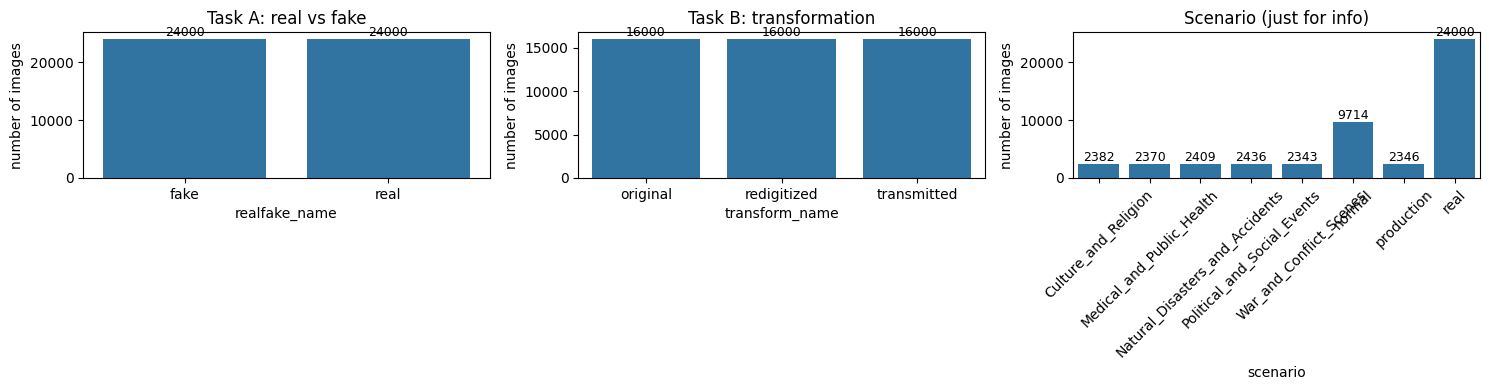

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_counts(subset.realfake_name,  "Task A: real vs fake",       axes[0])
bar_counts(subset.transform_name, "Task B: transformation",     axes[1])
bar_counts(subset.scenario,       "Scenario (just for info)",   axes[2])
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Split into train, validation and test by scene
We split the scenes, not the images, so all three versions of a scene stay together. First we
take off the training scenes, then we cut the rest in half into validation and test. Stratifying
keeps the real/fake ratio steady in every split.

In [40]:
if REBUILD:
    # One row per scene again, so we split scenes (not images): all 3 copies stay together.
    scenes = subset.drop_duplicates("base_id")[["base_id", "realfake"]]
    train_ratio, val_ratio, test_ratio = SPLIT_RATIOS

    # Step 1: take out the training scenes. "temp" holds validation + test for now.
    train_scenes, temp_scenes = train_test_split(
        scenes,
        test_size=val_ratio + test_ratio,          # e.g. 0.30 -> goes to val + test
        stratify=scenes["realfake"],               # keep real/fake balanced
        random_state=SEED,
    )

    # Step 2: cut "temp" in half into validation and test.
    val_scenes, test_scenes = train_test_split(
        temp_scenes,
        test_size=test_ratio / (val_ratio + test_ratio),   # half of temp -> test
        stratify=temp_scenes["realfake"],
        random_state=SEED,
    )

    # Give every image the split that its scene landed in.
    val_ids  = set(val_scenes["base_id"])
    test_ids = set(test_scenes["base_id"])
    subset["split"] = "train"                                  # everyone starts as train
    subset.loc[subset["base_id"].isin(val_ids),  "split"] = "val"
    subset.loc[subset["base_id"].isin(test_ids), "split"] = "test"

    print(subset["split"].value_counts(), "\n")
    print("Real/fake share inside each split (should stay about 50/50):")
    print(pd.crosstab(subset["split"], subset["realfake_name"], normalize="index").round(3))

split
train    33600
test      7200
val       7200
Name: count, dtype: int64 

Real/fake share inside each split (should stay about 50/50):
realfake_name  fake  real
split                    
test            0.5   0.5
train           0.5   0.5
val             0.5   0.5


### Prove there is no leakage
The most important correctness check: a scene must live in exactly one split. If any scene
appears in two splits, one of these asserts stops the notebook. This runs on the loaded table too.

In [41]:
train_ids = set(subset[subset.split == "train"].base_id)
val_ids   = set(subset[subset.split == "val"].base_id)
test_ids  = set(subset[subset.split == "test"].base_id)

assert train_ids.isdisjoint(val_ids),  "Leak: a scene is in both train and val!"
assert train_ids.isdisjoint(test_ids), "Leak: a scene is in both train and test!"
assert val_ids.isdisjoint(test_ids),   "Leak: a scene is in both val and test!"

print("No leakage: every scene is in exactly one split.")
print(f"  train: {len(train_ids)} scenes | val: {len(val_ids)} | test: {len(test_ids)}")

No leakage: every scene is in exactly one split.
  train: 11200 scenes | val: 2400 | test: 2400


### Save the table
Later reruns just load this CSV instead of scanning the folders again.

In [42]:
if REBUILD:
    subset.to_csv(INDEX_CSV, index=False)
    print("Saved the image table to:", INDEX_CSV.resolve())
subset.head()

Saved the image table to: /kaggle/working/rrdataset_index.csv


,path,realfake,realfake_name,transform,transform_name,base_id,scenario,split
0,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_002233,real,train
1,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_000837,real,test
2,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_005864,real,test
3,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_009458,real,val
4,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_004735,real,test


## Network
The models. A frozen DINOv3 backbone turns each image into 768 numbers, then small heads turn
those numbers into answers. We also define the joint model and the LoRA model here.

### Log in to HuggingFace
DINOv3 is a gated model, so we need a token to download it. On Kaggle the token is a Secret, on
a local machine it is the HF_TOKEN global or environment variable.

In [43]:
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")   # Kaggle
except Exception:
    hf_token = HF_TOKEN or os.environ.get("HF_TOKEN")       # local: global above, or env var

if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("No HF_TOKEN found.")

Logged in to HuggingFace.


### Load the frozen backbone
We do not train the backbone, so we lock its weights and put it in eval mode. It is used only as
a fixed image to numbers converter.

In [44]:
processor = AutoImageProcessor.from_pretrained(BACKBONE_ID)
backbone = AutoModel.from_pretrained(BACKBONE_ID).to(device).eval()
for p in backbone.parameters():
    p.requires_grad = False
print("Loaded backbone:", BACKBONE_ID)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loaded backbone: facebook/dinov3-vitb16-pretrain-lvd1689m


### Extract and cache the features
Because the backbone is frozen, an image always gives the same vector. We compute every vector
once, save them to feats.npy, and reuse them.

In [45]:
if FEATS_NPY.exists():
    feats = np.load(FEATS_NPY)
    print("Loaded cached features:", feats.shape)
else:
    feats = extract_features(subset["path"].tolist())
    np.save(FEATS_NPY, feats)
    print("\nSaved features:", feats.shape)

assert feats.shape[0] == len(subset)
assert feats.shape[1] == FEATURE_DIM

  48000 / 48000 images
Saved features: (48000, 768)


### Extract and cache the FFT descriptor
The frequency counterpart of the cell above: one azimuthally averaged FFT spectrum per image,
cached like the CLS features. We standardize it on the training rows only (no leakage, and the
LoRA image path reuses the same stats), then build `feats_fft` = CLS + standardized FFT. The two
arrays feed the two independent families of models.

In [46]:
if FFT_FEATS_NPY.exists():
    fft_feats = np.load(FFT_FEATS_NPY)
    print("Loaded cached FFT features:", fft_feats.shape)
else:
    fft_feats = extract_fft_features(subset["path"].tolist())
    np.save(FFT_FEATS_NPY, fft_feats)
    print("\nSaved FFT features:", fft_feats.shape)

assert fft_feats.shape == (len(subset), FFT_BINS)

train_rows = (subset["split"] == "train").values            # fit the scaler on train only
FFT_MEAN = fft_feats[train_rows].mean(axis=0)
FFT_STD  = fft_feats[train_rows].std(axis=0) + 1e-6
feats_fft = np.concatenate([feats, ((fft_feats - FFT_MEAN) / FFT_STD).astype(np.float32)], axis=1)
print("Combined feature dim (CLS + FFT):", feats_fft.shape[1])

  48000 / 48000 images
Saved FFT features: (48000, 128)
Combined feature dim (CLS + FFT): 896


### The single-task head [BASELINE]
A small MLP: 768 -> 256 -> GELU -> Dropout -> classes. We use the same class for both baselines,
only the number of output classes changes (2 for real/fake, 3 for the transformation).

In [47]:
class MLPHead(nn.Module):
    def __init__(self, n_classes, in_dim=FEATURE_DIM, hidden=HIDDEN_DIM, p_drop=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)

### The joint model [JOINT MODEL]
One model for both tasks: a shared trunk (768 -> hidden -> GELU -> Dropout) that both tasks
train, then one head each. The shared trunk is where the two tasks can help or hurt each other.

In [48]:
class JointModel(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM, hidden=HIDDEN_DIM, p_drop=DROPOUT):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(p_drop),
        )
        self.head_a = nn.Linear(hidden, 2)   # real vs fake
        self.head_b = nn.Linear(hidden, 3)   # transformation

    def forward(self, x):
        z = self.trunk(x)
        return self.head_a(z), self.head_b(z)

### The LoRA model [LORA]
Same shared-trunk plus two-heads idea, but now the backbone is not frozen: LoRA adds tiny
trainable adapters inside it, so the backbone can keep a bit of the degradation detail it would
normally throw away. It works on images, not cached features, and trains only adapters plus
trunk plus heads (the original backbone weights stay fixed).

In [49]:
class LoRAJointModel(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, p_drop=DROPOUT, in_dim=FEATURE_DIM):
        super().__init__()
        base = AutoModel.from_pretrained(BACKBONE_ID)
        lora_cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05,
                              target_modules="all-linear", bias="none")
        self.backbone = get_peft_model(base, lora_cfg)   # base frozen, adapters trainable
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, hidden),                   # in_dim = FEATURE_DIM (+ FFT_BINS for the FFT model)
            nn.GELU(),
            nn.Dropout(p_drop),
        )
        self.head_a = nn.Linear(hidden, 2)
        self.head_b = nn.Linear(hidden, 3)

    def forward(self, pixel_values, fft=None):
        cls = self.backbone(pixel_values=pixel_values).last_hidden_state[:, 0]
        if fft is not None and fft.shape[-1] > 0:        # concat the (fixed) FFT descriptor
            cls = torch.cat([cls, fft.to(cls.dtype)], dim=1)
        z = self.trunk(cls)
        return self.head_a(z), self.head_b(z)

## Train
Perform an hyperparameter search then train the two single-task baselines on the cached features, then the joint model (with the
loss-weight and bottleneck sweep), and finally the LoRA model.

### Build the training tensors
Call the Utils helper now that the cached features and the table both exist.

In [50]:
cls_data = make_splits(feats, subset, "cls")        # CLS features
fft_data = make_splits(feats_fft, subset, "fft")    # CLS + FFT features

print("train / val / test:", int(cls_data.is_train.sum()), int(cls_data.is_val.sum()), int(cls_data.is_test.sum()))
print("feature dim: CLS", cls_data.in_dim, "| CLS+FFT", fft_data.in_dim)

train / val / test: 33600 7200 7200
feature dim: CLS 768 | CLS+FFT 896


### The single-task training loop [BASELINE]
One loop reused for both baselines. AdamW plus cross-entropy, keeping the weights with the best
validation accuracy, and stopping early if validation stops improving.

In [51]:
def train_head(data, n_classes, y_all, hidden=HIDDEN_DIM, p_drop=DROPOUT, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    set_seed(SEED)   # deterministic weight init for every call
    head = MLPHead(n_classes=n_classes, in_dim=data.in_dim, hidden=hidden, p_drop=p_drop).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr, ytr = data.feats[data.is_train], y_all[data.is_train]
    Xval, yval = data.feats[data.is_val], y_all[data.is_val]
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state, no_improve = 0.0, None, 0
    for epoch in range(epochs):
        head.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(head(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        history["train_loss"].append(epoch_loss / len(Xtr))
        history["train_acc"].append(accuracy(head, Xtr, ytr))
        val_acc = accuracy(head, Xval, yval)
        history["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state, no_improve = val_acc, copy.deepcopy(head.state_dict()), 0
        else:
            no_improve += 1
        print(f"  epoch {epoch + 1:2d}/{epochs} | val acc {val_acc:.3f}", end="\r")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1} (no val improvement for {PATIENCE} epochs).")
            break

    head.load_state_dict(best_state)
    print(f"\nBest validation accuracy: {best_acc:.3f}")
    return head, history

### The joint training loop [JOINT MODEL]
Trains the joint model on the combined loss w_A * loss_A + w_B * loss_B, keeping the weights with
the best average validation accuracy. We re-seed at the start so every run begins the same way.

In [52]:
def train_joint(data, w_a, w_b, hidden=HIDDEN_DIM, p_drop=DROPOUT, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    set_seed(SEED)   # same start for every run, so only the weights differ
    model = JointModel(in_dim=data.in_dim, hidden=hidden, p_drop=p_drop).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr = data.feats[data.is_train]
    ya_tr, yb_tr = data.y_a[data.is_train], data.y_b[data.is_train]
    loader = DataLoader(TensorDataset(Xtr, ya_tr, yb_tr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    best_score, best_state, no_improve = 0.0, None, 0
    for epoch in range(epochs):
        model.train()
        for xb, ya, yb in loader:
            xb, ya, yb = xb.to(device), ya.to(device), yb.to(device)
            optimizer.zero_grad()
            out_a, out_b = model(xb)
            loss = w_a * loss_fn(out_a, ya) + w_b * loss_fn(out_b, yb)
            loss.backward()
            optimizer.step()
        acc_a, acc_b = joint_accuracy(model, data, data.is_val)
        score = (acc_a + acc_b) / 2
        if score > best_score:
            best_score, best_state, no_improve = score, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
        print(f"  epoch {epoch + 1:2d}/{epochs} | val A {acc_a:.3f} | val B {acc_b:.3f}", end="\r")
        if no_improve >= PATIENCE:
            break

    model.load_state_dict(best_state)
    print()
    return model

### Hyperparameter grid search
We use sklearn's ParameterGrid to try a few settings for each network and pick the best on
validation accuracy. Each baseline is then trained with its own best config, and the joint
model's best config feeds the sweep, so every final result uses tuned settings (not defaults).

In [53]:
param_grid = {"lr": [1e-3, 3e-4], "hidden": [128, 256], "dropout": [0.1, 0.3]}

def grid_search_head(data, n_classes, y_all):
    rows = []
    for p in ParameterGrid(param_grid):
        _, hist = train_head(data, n_classes, y_all, hidden=p["hidden"], p_drop=p["dropout"], lr=p["lr"])
        rows.append({**p, "val_acc": max(hist["val_acc"])})
    return pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)

def grid_search_joint(data):
    rows = []
    for p in ParameterGrid(param_grid):
        model = train_joint(data, 1.0, 1.0, hidden=p["hidden"], p_drop=p["dropout"], lr=p["lr"])
        acc_a, acc_b = joint_accuracy(model, data, data.is_val)
        rows.append({**p, "val_acc": (acc_a + acc_b) / 2})
    return pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)

def run_grid_search(data):
    """Grid-search both baselines and the joint model on one feature set; return the three tables."""
    gA = grid_search_head(data, 2, data.y_a)
    gB = grid_search_head(data, 3, data.y_b)
    gJ = grid_search_joint(data)
    for name, g in [("taskA", gA), ("taskB", gB), ("joint", gJ)]:
        g.to_csv(OUT_DIR / f"grid_{name}_{data.tag}.csv", index=False)
        print(f"[{data.tag}] best for {name}: {g.iloc[0].to_dict()}")
    return gA, gB, gJ

### Grid search [BASELINE / JOINT]
Tune the models on each feature set independently. We start one `Trained` per feature set and
store its grid tables and best config; the best joint config feeds that feature set's trunk sweep.

In [54]:
trained = {data.tag: Trained(data=data) for data in (cls_data, fft_data)}

for t in trained.values():
    print(f"\n=== grid search [{t.data.tag}] ===")
    t.grid_a, t.grid_b, t.grid_joint = run_grid_search(t.data)
    bj = t.grid_joint.iloc[0]
    t.best = {"taskA": t.grid_a.iloc[0], "taskB": t.grid_b.iloc[0],
              "lr": float(bj["lr"]), "hidden": int(bj["hidden"]), "dropout": float(bj["dropout"])}
    print(f"[{t.data.tag}] joint sweep will use: lr={t.best['lr']}, hidden={t.best['hidden']}, dropout={t.best['dropout']}")
    display(t.grid_a, t.grid_b, t.grid_joint)


=== grid search [cls] ===
  epoch 25/50 | val acc 0.943
Early stopping at epoch 25 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 33/50 | val acc 0.943
Early stopping at epoch 33 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 26/50 | val acc 0.948
Early stopping at epoch 26 (no val improvement for 8 epochs).

Best validation accuracy: 0.948
  epoch 48/50 | val acc 0.947
Early stopping at epoch 48 (no val improvement for 8 epochs).

Best validation accuracy: 0.947
  epoch 24/50 | val acc 0.941
Early stopping at epoch 24 (no val improvement for 8 epochs).

Best validation accuracy: 0.945
  epoch 28/50 | val acc 0.942
Early stopping at epoch 28 (no val improvement for 8 epochs).

Best validation accuracy: 0.944
  epoch 16/50 | val acc 0.945
Early stopping at epoch 16 (no val improvement for 8 epochs).

Best validation accuracy: 0.947
  epoch 32/50 | val acc 0.947
Early stopping at epoch 32 (no val improvement for 8 epochs).

Best 

,dropout,hidden,lr,val_acc
0,0.1,256,0.0010,0.948194
1,0.3,256,0.0003,0.948056
2,0.1,256,0.0003,0.946806
3,0.3,256,0.0010,0.946528
4,0.3,128,0.0010,0.945417
5,0.3,128,0.0003,0.944444
6,0.1,128,0.0010,0.944306
7,0.1,128,0.0003,0.944167


,dropout,hidden,lr,val_acc
0,0.1,128,0.0003,0.889444
1,0.3,128,0.0003,0.888194
2,0.3,256,0.0003,0.887361
3,0.1,256,0.0003,0.887222
4,0.3,128,0.0010,0.884722
5,0.1,256,0.0010,0.884306
6,0.3,256,0.0010,0.884306
7,0.1,128,0.0010,0.883472


,dropout,hidden,lr,val_acc
0,0.3,256,0.0003,0.917708
1,0.3,256,0.0010,0.916042
2,0.1,256,0.0003,0.915625
3,0.1,256,0.0010,0.914097
4,0.3,128,0.0003,0.913333
5,0.3,128,0.0010,0.913333
6,0.1,128,0.0003,0.912431
7,0.1,128,0.0010,0.911250



=== grid search [fft] ===
  epoch 24/50 | val acc 0.948
Early stopping at epoch 24 (no val improvement for 8 epochs).

Best validation accuracy: 0.951
  epoch 24/50 | val acc 0.948
Early stopping at epoch 24 (no val improvement for 8 epochs).

Best validation accuracy: 0.948
  epoch 15/50 | val acc 0.949
Early stopping at epoch 15 (no val improvement for 8 epochs).

Best validation accuracy: 0.950
  epoch 50/50 | val acc 0.952
Best validation accuracy: 0.952
  epoch 29/50 | val acc 0.946
Early stopping at epoch 29 (no val improvement for 8 epochs).

Best validation accuracy: 0.954
  epoch 49/50 | val acc 0.950
Early stopping at epoch 49 (no val improvement for 8 epochs).

Best validation accuracy: 0.952
  epoch 16/50 | val acc 0.949
Early stopping at epoch 16 (no val improvement for 8 epochs).

Best validation accuracy: 0.951
  epoch 28/50 | val acc 0.950
Early stopping at epoch 28 (no val improvement for 8 epochs).

Best validation accuracy: 0.950
  epoch 29/50 | val acc 0.892
Early 

,dropout,hidden,lr,val_acc
0,0.3,128,0.0010,0.953750
1,0.3,128,0.0003,0.952222
2,0.1,256,0.0003,0.951944
3,0.1,128,0.0010,0.951389
4,0.3,256,0.0010,0.950556
5,0.3,256,0.0003,0.950278
6,0.1,256,0.0010,0.949861
7,0.1,128,0.0003,0.948333


,dropout,hidden,lr,val_acc
0,0.3,256,0.0003,0.900278
1,0.3,128,0.0003,0.899444
2,0.1,128,0.0003,0.898194
3,0.1,256,0.0010,0.896667
4,0.3,256,0.0010,0.896667
5,0.1,256,0.0003,0.896111
6,0.1,128,0.0010,0.894722
7,0.3,128,0.0010,0.894306


,dropout,hidden,lr,val_acc
0,0.3,128,0.0003,0.923333
1,0.3,256,0.0003,0.923056
2,0.3,256,0.0010,0.922986
3,0.3,128,0.0010,0.922569
4,0.1,256,0.0003,0.922222
5,0.1,128,0.0010,0.922153
6,0.1,128,0.0003,0.922153
7,0.1,256,0.0010,0.920625


### Baselines [BASELINE]
For each feature set, train the two single-task heads with their best grid-search configs.

In [55]:
for t in trained.values():
    print(f"\n=== baselines [{t.data.tag}] ===")
    a, b = t.best["taskA"], t.best["taskB"]
    t.head_a, t.hist_a = train_head(t.data, 2, t.data.y_a,
                                    hidden=int(a["hidden"]), p_drop=float(a["dropout"]), lr=float(a["lr"]))
    t.head_b, t.hist_b = train_head(t.data, 3, t.data.y_b,
                                    hidden=int(b["hidden"]), p_drop=float(b["dropout"]), lr=float(b["lr"]))


=== baselines [cls] ===
  epoch 26/50 | val acc 0.948
Early stopping at epoch 26 (no val improvement for 8 epochs).

Best validation accuracy: 0.948
  epoch 31/50 | val acc 0.886
Early stopping at epoch 31 (no val improvement for 8 epochs).

Best validation accuracy: 0.889

=== baselines [fft] ===
  epoch 29/50 | val acc 0.946
Early stopping at epoch 29 (no val improvement for 8 epochs).

Best validation accuracy: 0.954
  epoch 45/50 | val acc 0.899
Early stopping at epoch 45 (no val improvement for 8 epochs).

Best validation accuracy: 0.900


### Training curves of the baselines [BASELINE]
Loss and accuracy per epoch for every baseline, to check they learned and did not overfit.

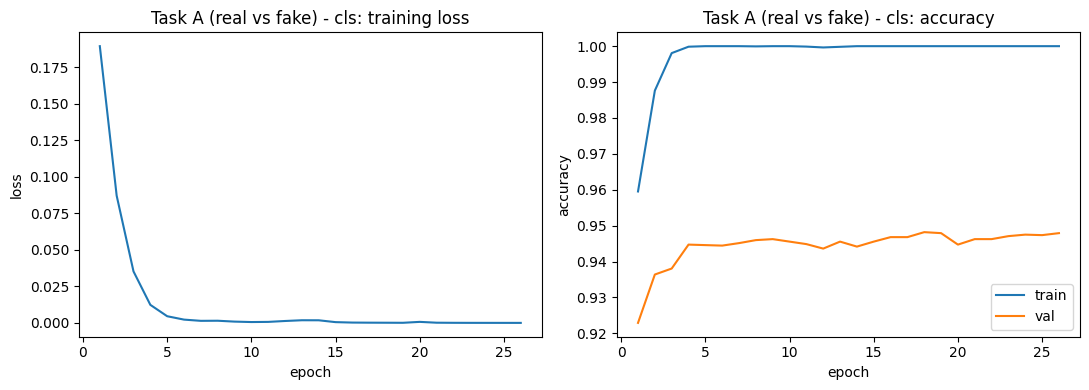

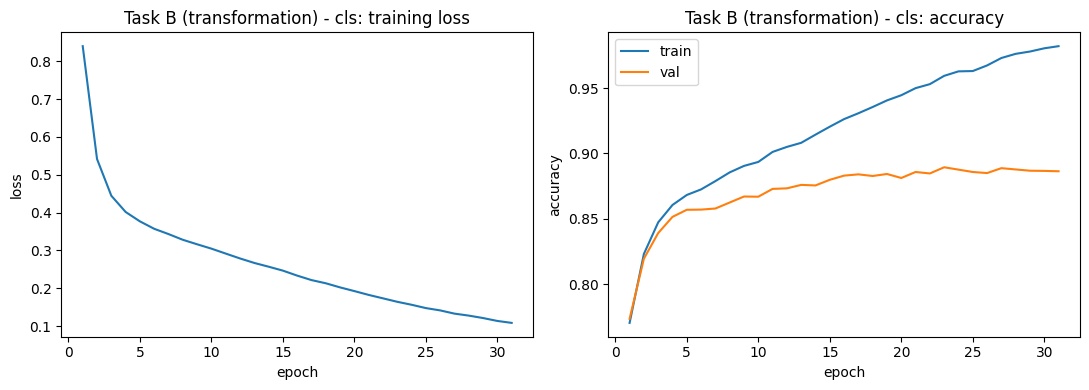

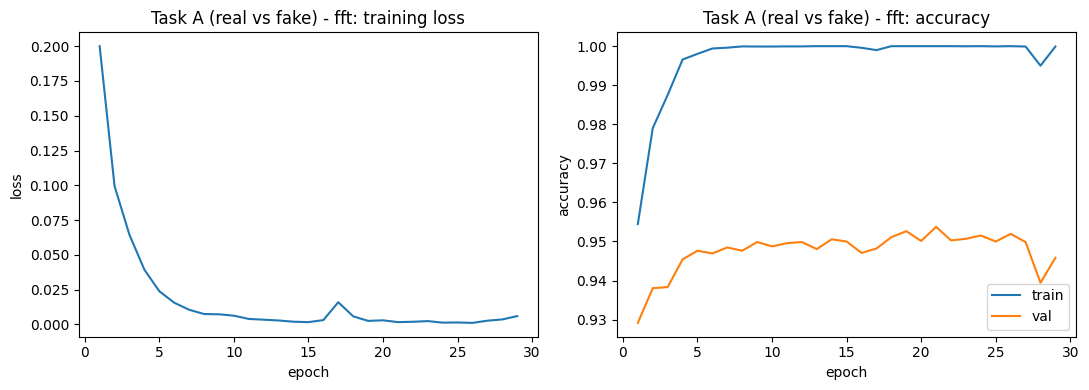

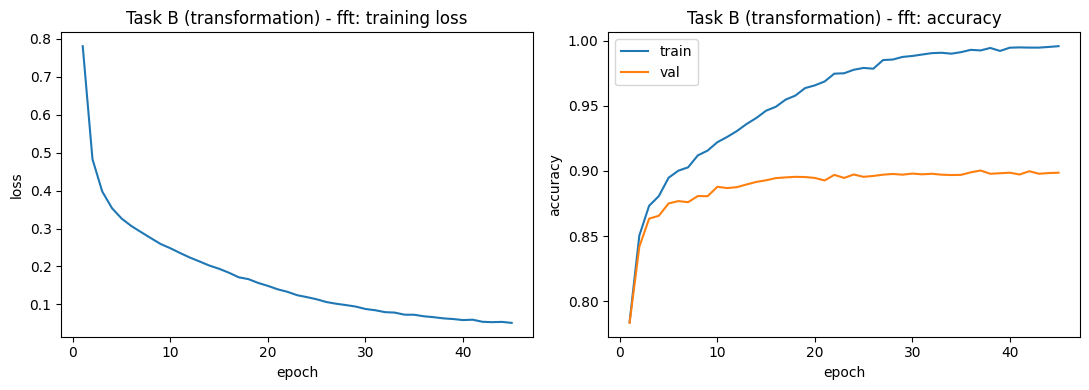

In [56]:
for t in trained.values():
    plot_curves(t.hist_a, f"Task A (real vs fake) - {t.data.tag}")
    plot_curves(t.hist_b, f"Task B (transformation) - {t.data.tag}")

### Loss-weight and bottleneck sweep [JOINT MODEL]
Using the joint model's best settings from the grid search, we sweep w_B (with w_A = 1) for
several trunk sizes. The best trunk size is the main model; 1, 2, 4, 8 are bottlenecks that force
the tasks to share. Every model here is scored on validation only (the test set stays untouched
until the final evaluation). We keep the single best-on-validation model to start LoRA from, and
pull the main-trunk rows out as `sweep`.

In [57]:
def run_sweep(data, best_hidden, best_lr, best_dropout):
    """Sweep w_B over several trunk sizes on one feature set (validation only).

    Returns the best-on-validation joint model, its w_B, the full bottleneck table, the main-trunk
    rows (`sweep`), and the list of trunk sizes tried."""
    hidden_sizes = sorted(set([1, 2, 4, 8, best_hidden]))   # small trunks + the best (main) trunk
    ratios = [0, 0.25, 0.5, 1, 2, 4]                         # this is w_B (with w_A fixed to 1)

    rows = []
    best_model, best_val, best_ratio = None, -1.0, 0
    for hidden in hidden_sizes:
        for w_b in ratios:
            model = train_joint(data, 1.0, w_b, hidden=hidden, p_drop=best_dropout, lr=best_lr)
            acc_a, acc_b = joint_accuracy(model, data, data.is_val)   # validation only
            rows.append({"hidden": hidden, "w_A": 1.0, "w_B": w_b, "lr": best_lr,
                         "dropout": best_dropout, "seed": SEED,
                         "taskA_val": acc_a, "taskB_val": acc_b})
            print(f"[{data.tag}] hidden={hidden:3d} w_B={w_b}: val A {acc_a:.3f} | val B {acc_b:.3f}")
            score = (acc_a + acc_b) / 2
            if score > best_val:
                best_val, best_model, best_ratio = score, model, w_b

    bottleneck = pd.DataFrame(rows)
    bottleneck.to_csv(OUT_DIR / f"bottleneck_ablation_{data.tag}.csv", index=False)
    sweep = bottleneck[bottleneck["hidden"] == best_hidden].reset_index(drop=True)
    sweep.to_csv(OUT_DIR / f"loss_weight_sweep_{data.tag}.csv", index=False)
    print(f"\n[{data.tag}] best joint model: hidden={best_model.trunk[0].out_features}, ratio={best_ratio}, val score={best_val:.3f}")
    return best_model, best_ratio, bottleneck, sweep, hidden_sizes

### Trunk sweep [JOINT MODEL]
Sweep w_B over several trunk sizes for each feature set, keeping the best joint model of each.

In [58]:
for t in trained.values():
    print(f"\n=== trunk sweep [{t.data.tag}] ===")
    t.joint, t.ratio, t.bottleneck, t.sweep, t.hidden_sizes = run_sweep(
        t.data, t.best["hidden"], t.best["lr"], t.best["dropout"])
display(trained["cls"].sweep, trained["fft"].sweep)


=== trunk sweep [cls] ===
  epoch  9/50 | val A 0.500 | val B 0.339
[cls] hidden=  1 w_B=0: val A 0.500 | val B 0.343
  epoch 46/50 | val A 0.917 | val B 0.349
[cls] hidden=  1 w_B=0.25: val A 0.917 | val B 0.350
  epoch 46/50 | val A 0.918 | val B 0.350
[cls] hidden=  1 w_B=0.5: val A 0.918 | val B 0.351
  epoch 39/50 | val A 0.918 | val B 0.355
[cls] hidden=  1 w_B=1: val A 0.916 | val B 0.359
  epoch 22/50 | val A 0.502 | val B 0.603
[cls] hidden=  1 w_B=2: val A 0.611 | val B 0.559
  epoch 50/50 | val A 0.506 | val B 0.667
[cls] hidden=  1 w_B=4: val A 0.509 | val B 0.666
  epoch 30/50 | val A 0.918 | val B 0.333
[cls] hidden=  2 w_B=0: val A 0.920 | val B 0.336
  epoch 16/50 | val A 0.920 | val B 0.364
[cls] hidden=  2 w_B=0.25: val A 0.912 | val B 0.378
  epoch 50/50 | val A 0.913 | val B 0.684
[cls] hidden=  2 w_B=0.5: val A 0.915 | val B 0.689
  epoch 50/50 | val A 0.917 | val B 0.741
[cls] hidden=  2 w_B=1: val A 0.918 | val B 0.746
  epoch 49/50 | val A 0.915 | val B 0.742
[

,hidden,w_A,w_B,lr,dropout,seed,taskA_val,taskB_val
0,256,1.0,0.00,0.0003,0.3,42,0.948056,0.313750
1,256,1.0,0.25,0.0003,0.3,42,0.946944,0.887083
2,256,1.0,0.50,0.0003,0.3,42,0.945000,0.887361
3,256,1.0,1.00,0.0003,0.3,42,0.945556,0.889861
4,256,1.0,2.00,0.0003,0.3,42,0.945000,0.890972
5,256,1.0,4.00,0.0003,0.3,42,0.942778,0.890000


,hidden,w_A,w_B,lr,dropout,seed,taskA_val,taskB_val
0,128,1.0,0.00,0.0003,0.3,42,0.950417,0.341667
1,128,1.0,0.25,0.0003,0.3,42,0.950417,0.893333
2,128,1.0,0.50,0.0003,0.3,42,0.948611,0.895556
3,128,1.0,1.00,0.0003,0.3,42,0.947083,0.899583
4,128,1.0,2.00,0.0003,0.3,42,0.945556,0.899722
5,128,1.0,4.00,0.0003,0.3,42,0.944306,0.899583


### Train the LoRA model [LORA]
This trains through the backbone on the images, so it is the slow part. We use mixed precision
for speed, the same loss weights the best joint model used (w_A = 1, w_B = ratio), and we start
the trunk and heads from that joint model so LoRA only has to adapt the backbone. The result is
cached so reruns skip training.

In [59]:
def train_lora(data, init_from, w_b, w_a=1.0, epochs=LORA_EPOCHS, lr=LORA_LR, batch_size=LORA_BATCH):
    set_seed(SEED)
    use_fft = (data.tag == "fft")
    # Warm start: build the LoRA model with the same trunk size and input dim as its joint model,
    # then copy its trunk + heads, so LoRA only has to adapt the backbone.
    model = LoRAJointModel(hidden=init_from.trunk[0].out_features, in_dim=data.in_dim).to(device)
    model.trunk.load_state_dict(init_from.trunk.state_dict())
    model.head_a.load_state_dict(init_from.head_a.state_dict())
    model.head_b.load_state_dict(init_from.head_b.state_dict())
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    use_amp = (device.type == "cuda")          # mixed precision: run the backbone in fp16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    train_frame = subset[subset["split"] == "train"]
    loader = DataLoader(LabeledImageDataset(train_frame, use_fft=use_fft), batch_size=batch_size, shuffle=True,
                        num_workers=4, pin_memory=True, persistent_workers=True,
                        generator=torch.Generator().manual_seed(SEED))   # deterministic shuffling

    for epoch in range(epochs):
        model.train()
        for px, fft, ya, yb in loader:
            px, fft, ya, yb = px.to(device, non_blocking=True), fft.to(device), ya.to(device), yb.to(device)
            optimizer.zero_grad()
            with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
                out_a, out_b = model(px, fft)
                loss = w_a * loss_fn(out_a, ya) + w_b * loss_fn(out_b, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        print(f"  epoch {epoch + 1}/{epochs} done")
    return model

def build_lora(data, init_from, w_b):
    """Load the cached LoRA model if present (and not retraining), otherwise train and cache it."""
    weights_path = LORA_FFT_WEIGHTS if data.tag == "fft" else LORA_WEIGHTS
    hidden = init_from.trunk[0].out_features          # match the LoRA trunk to its joint model
    if RETRAIN_LORA and weights_path.exists():
        weights_path.unlink()
        print(f"[{data.tag}] removed stale LoRA cache:", weights_path)
    if weights_path.exists():
        model = LoRAJointModel(hidden=hidden, in_dim=data.in_dim).to(device)
        model.load_state_dict(torch.load(weights_path, map_location=device), strict=False)
        print(f"[{data.tag}] loaded saved LoRA weights, skipping training.")
    else:
        print(f"[{data.tag}] training LoRA model (this trains through the backbone, so it is slow)...")
        model = train_lora(data, init_from, w_b)   # same loss weight as its joint
        # save only the trainable params (adapters + trunk + heads) so the file stays small
        trainable = {n: p.detach().cpu() for n, p in model.named_parameters() if p.requires_grad}
        torch.save(trainable, weights_path)
        print(f"[{data.tag}] saved LoRA weights to:", weights_path)
    return model

### LoRA [LORA]
For each feature set, warm-start a LoRA model from its joint model (same loss weight) and adapt the
backbone. Cached per feature set so reruns skip the slow training.

In [60]:
for t in trained.values():
    print(f"\n=== LoRA [{t.data.tag}] ===")
    t.lora = build_lora(t.data, t.joint, t.ratio)


=== LoRA [cls] ===
[cls] training LoRA model (this trains through the backbone, so it is slow)...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch 1/3 done
  epoch 2/3 done
  epoch 3/3 done
[cls] saved LoRA weights to: /kaggle/working/lora_model.pt

=== LoRA [fft] ===
[fft] training LoRA model (this trains through the backbone, so it is slow)...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch 1/3 done
  epoch 2/3 done
  epoch 3/3 done
[fft] saved LoRA weights to: /kaggle/working/lora_fft_model.pt


## Evaluation
Score every model on the test split, each next to its FFT version, then compare the families and
repeat the breakdown plots once for the CLS models and once for the CLS + FFT models. Every model
is scored the same way, through the `*_preds` interface and `report_scores`.

### Evaluation setup
Shared test labels and scenario index, then every trained model's test predictions, computed once
through the uniform predict interface and stored in `model_preds` in the order we report them
(baseline, joint, LoRA - each CLS then CLS + FFT). Feature models and the image (LoRA) models score
the test rows in the same order, so one set of labels fits all.

In [61]:
test_frame = subset[subset["split"] == "test"]
y_true_a = cls_data.y_a[cls_data.is_test]
y_true_b = cls_data.y_b[cls_data.is_test]
transform_test = y_true_b
scen_test = subset["scenario"].values[cls_data.is_test.numpy()]

model_preds = {}
for t in trained.values():
    model_preds[f"baseline ({t.data.tag})"] = baseline_preds(t.head_a, t.head_b, t.data)
for t in trained.values():
    model_preds[f"joint ({t.data.tag})"] = joint_preds(t.joint, t.data)
for t in trained.values():
    model_preds[f"LoRA ({t.data.tag})"] = lora_preds(t.lora, t.data)

### Compete or complement + trade-off by trunk size [JOINT MODEL]
The joint trade-off, shown for the CLS sweep and then the CLS + FFT sweep.

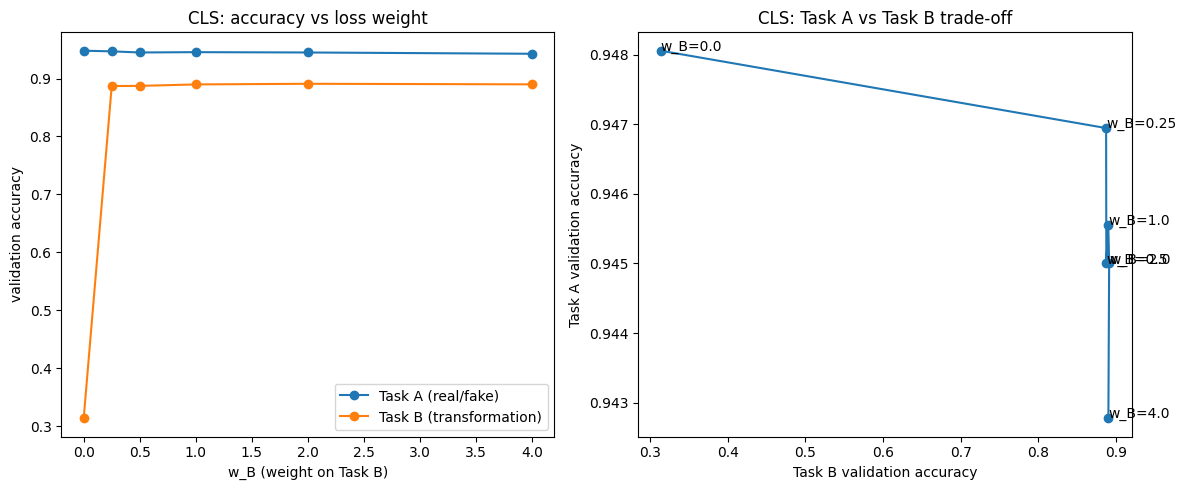

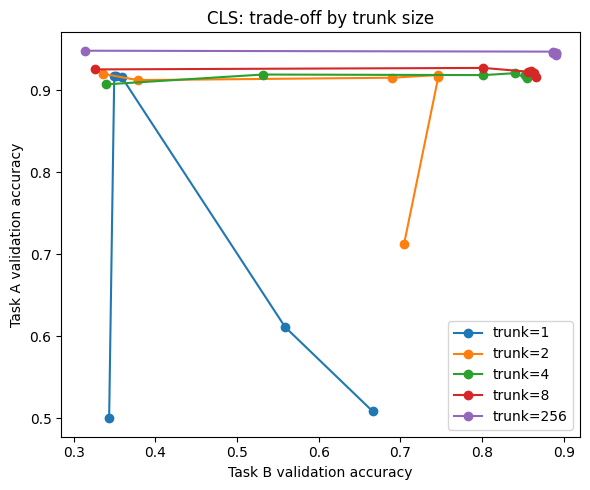

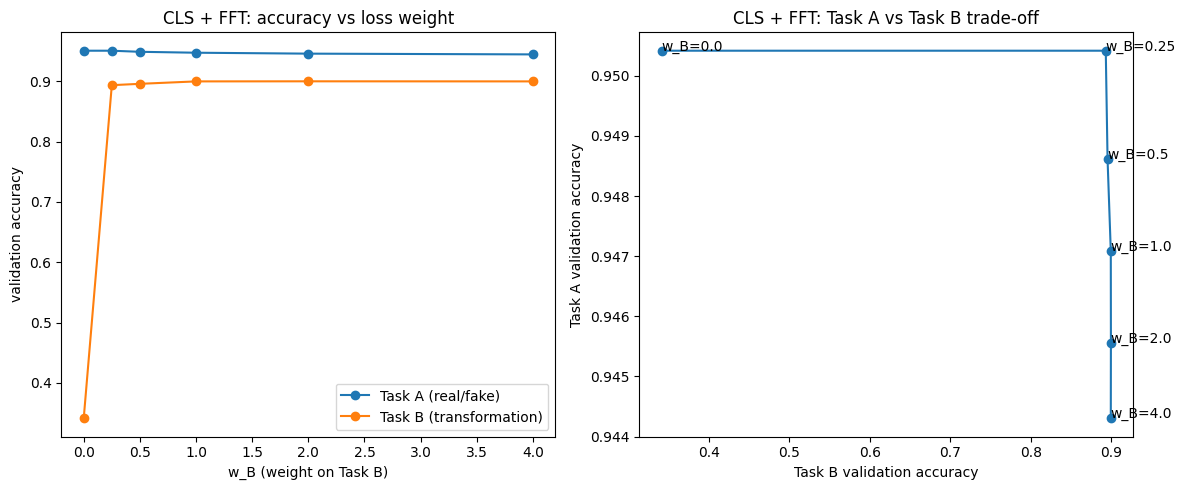

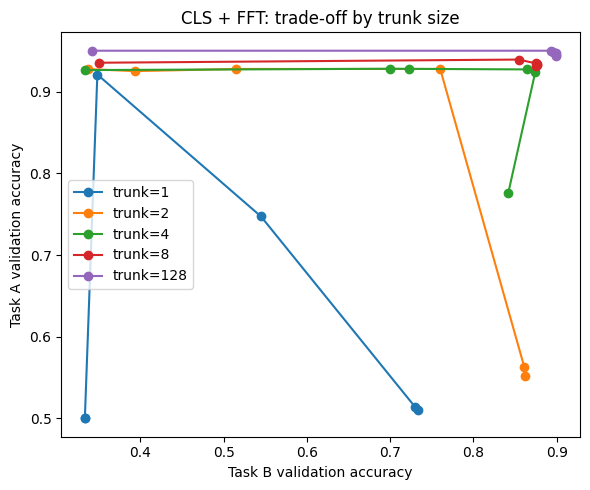

In [62]:
plot_trunk_sweep(trained["cls"].sweep, trained["cls"].bottleneck, trained["cls"].hidden_sizes, "CLS")
plot_trunk_sweep(trained["fft"].sweep, trained["fft"].bottleneck, trained["fft"].hidden_sizes, "CLS + FFT")

### Per-model scores and confusion matrices [BASELINE / JOINT / LORA]
Each model next to its FFT version, in order: baseline, joint, LoRA. `report_scores` prints the
Task A / Task B accuracy (plus AUC where available) and draws both confusion matrices; we keep the
accuracies for the comparison tables below.

baseline (cls) - Task A (real vs fake)
  accuracy      : 0.943
  real accuracy : 0.934
  fake accuracy : 0.952
  AUC           : 0.986
baseline (cls) - Task B (transformation)
  accuracy      : 0.877


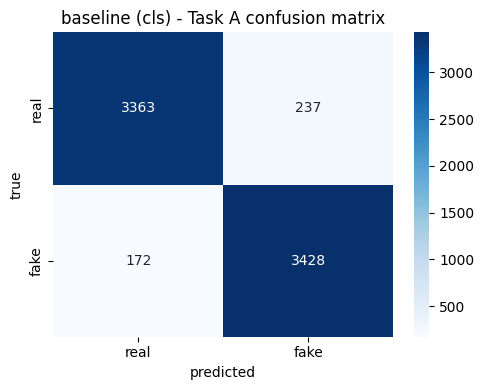

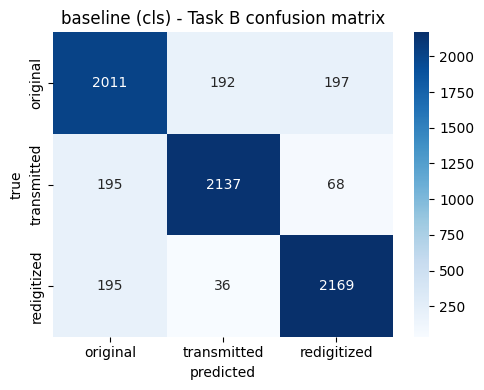

baseline (cls) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.951,0.934,0.943,3600.000
fake,0.935,0.952,0.944,3600.000
accuracy,0.943,0.943,0.943,0.943
macro avg,0.943,0.943,0.943,7200.000
weighted avg,0.943,0.943,0.943,7200.000


baseline (cls) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.838,0.838,0.838,2400.000
transmitted,0.904,0.890,0.897,2400.000
redigitized,0.891,0.904,0.897,2400.000
accuracy,0.877,0.877,0.877,0.877
macro avg,0.877,0.877,0.877,7200.000
weighted avg,0.877,0.877,0.877,7200.000


baseline (fft) - Task A (real vs fake)
  accuracy      : 0.949
  real accuracy : 0.938
  fake accuracy : 0.960
  AUC           : 0.988
baseline (fft) - Task B (transformation)
  accuracy      : 0.893


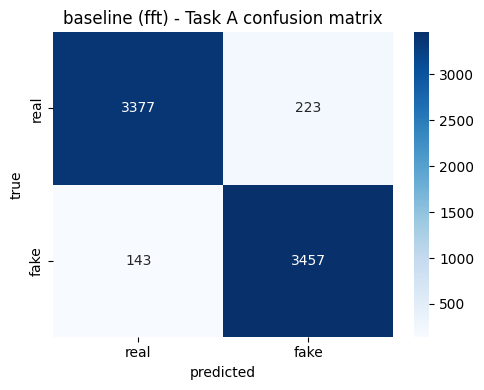

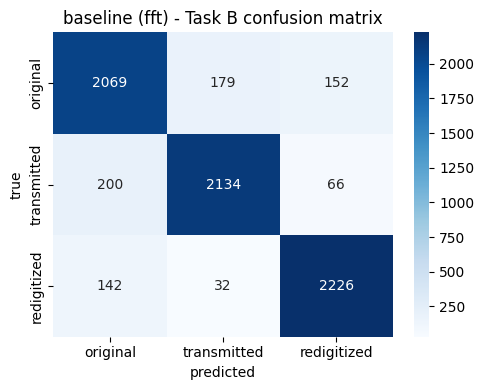

baseline (fft) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.959,0.938,0.949,3600.000
fake,0.939,0.960,0.950,3600.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.949,0.949,0.949,7200.000
weighted avg,0.949,0.949,0.949,7200.000


baseline (fft) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.858,0.862,0.860,2400.000
transmitted,0.910,0.889,0.899,2400.000
redigitized,0.911,0.928,0.919,2400.000
accuracy,0.893,0.893,0.893,0.893
macro avg,0.893,0.893,0.893,7200.000
weighted avg,0.893,0.893,0.893,7200.000


joint (cls) - Task A (real vs fake)
  accuracy      : 0.940
  real accuracy : 0.933
  fake accuracy : 0.948
  AUC           : 0.986
joint (cls) - Task B (transformation)
  accuracy      : 0.881


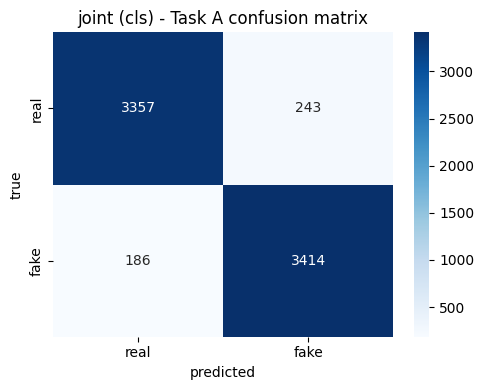

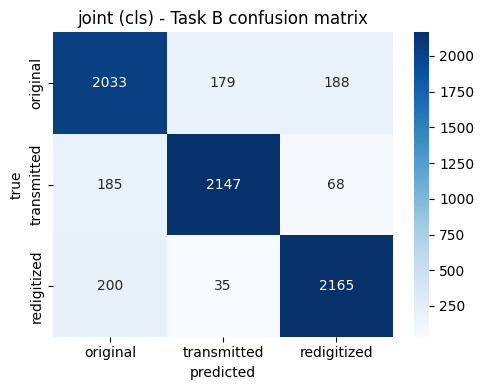

joint (cls) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.948,0.932,0.940,3600.00
fake,0.934,0.948,0.941,3600.00
accuracy,0.940,0.940,0.940,0.94
macro avg,0.941,0.940,0.940,7200.00
weighted avg,0.941,0.940,0.940,7200.00


joint (cls) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.841,0.847,0.844,2400.000
transmitted,0.909,0.895,0.902,2400.000
redigitized,0.894,0.902,0.898,2400.000
accuracy,0.881,0.881,0.881,0.881
macro avg,0.881,0.881,0.881,7200.000
weighted avg,0.881,0.881,0.881,7200.000


joint (fft) - Task A (real vs fake)
  accuracy      : 0.950
  real accuracy : 0.940
  fake accuracy : 0.959
  AUC           : 0.988
joint (fft) - Task B (transformation)
  accuracy      : 0.889


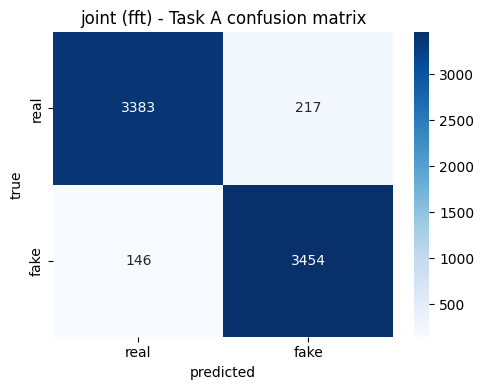

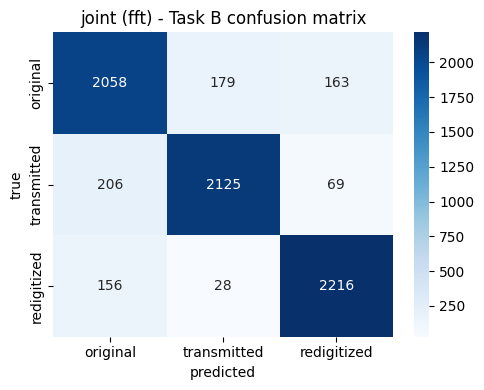

joint (fft) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.959,0.940,0.949,3600.00
fake,0.941,0.959,0.950,3600.00
accuracy,0.950,0.950,0.950,0.95
macro avg,0.950,0.950,0.950,7200.00
weighted avg,0.950,0.950,0.950,7200.00


joint (fft) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.850,0.858,0.854,2400.000
transmitted,0.911,0.885,0.898,2400.000
redigitized,0.905,0.923,0.914,2400.000
accuracy,0.889,0.889,0.889,0.889
macro avg,0.889,0.889,0.889,7200.000
weighted avg,0.889,0.889,0.889,7200.000


LoRA (cls) - Task A (real vs fake)
  accuracy      : 0.947
  real accuracy : 0.936
  fake accuracy : 0.957
LoRA (cls) - Task B (transformation)
  accuracy      : 0.949


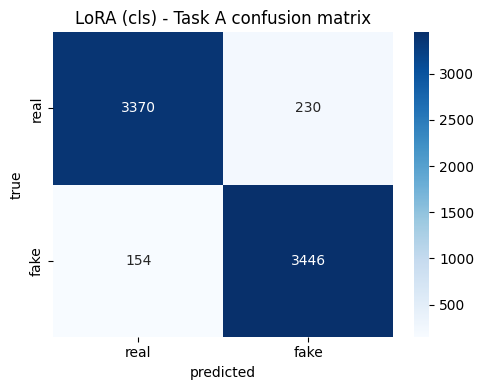

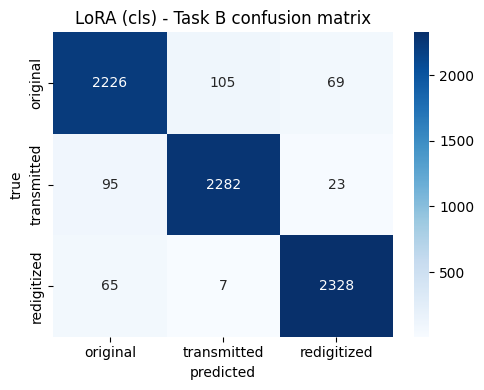

LoRA (cls) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.956,0.936,0.946,3600.000
fake,0.937,0.957,0.947,3600.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.947,0.947,0.947,7200.000
weighted avg,0.947,0.947,0.947,7200.000


LoRA (cls) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.933,0.928,0.930,2400.000
transmitted,0.953,0.951,0.952,2400.000
redigitized,0.962,0.970,0.966,2400.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.949,0.949,0.949,7200.000
weighted avg,0.949,0.949,0.949,7200.000


LoRA (fft) - Task A (real vs fake)
  accuracy      : 0.957
  real accuracy : 0.950
  fake accuracy : 0.964
LoRA (fft) - Task B (transformation)
  accuracy      : 0.964


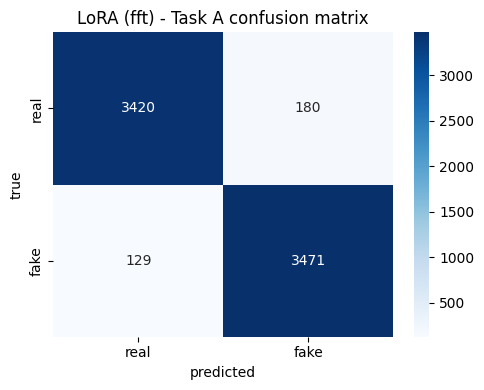

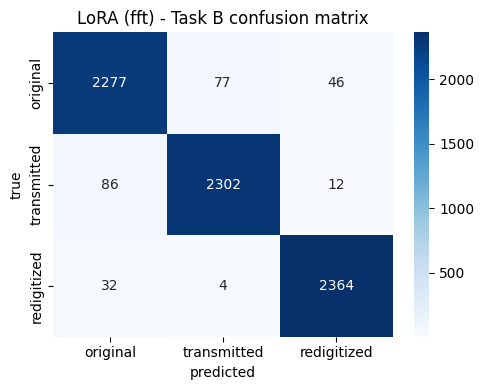

LoRA (fft) - Task A precision / recall / F1:


,precision,recall,f1-score,support
real,0.964,0.950,0.957,3600.000
fake,0.951,0.964,0.957,3600.000
accuracy,0.957,0.957,0.957,0.957
macro avg,0.957,0.957,0.957,7200.000
weighted avg,0.957,0.957,0.957,7200.000


LoRA (fft) - Task B precision / recall / F1:


,precision,recall,f1-score,support
original,0.951,0.949,0.950,2400.000
transmitted,0.966,0.959,0.963,2400.000
redigitized,0.976,0.985,0.981,2400.000
accuracy,0.964,0.964,0.964,0.964
macro avg,0.964,0.964,0.964,7200.000
weighted avg,0.964,0.964,0.964,7200.000


In [63]:
accs = {}
for name, p in model_preds.items():
    accs[name] = report_scores(y_true_a, p.a, y_true_b, p.b, name, proba_fake=p.proba_fake)

### Baseline vs joint vs LoRA [CLS]
The three CLS models side by side on the test set.

In [64]:
def acc_table(keys, index):
    return pd.DataFrame({"Task A acc": [accs[k][0] for k in keys],
                         "Task B acc": [accs[k][1] for k in keys]}, index=index).round(3)

kinds = ["baseline", "joint", "LoRA"]
display(acc_table([f"{k} (cls)" for k in kinds], kinds))

,Task A acc,Task B acc
baseline,0.943,0.877
joint,0.940,0.881
LoRA,0.947,0.949


### Baseline vs joint vs LoRA [CLS + FFT]
The same comparison for the three FFT models.

In [65]:
display(acc_table([f"{k} (fft)" for k in kinds], [f"{k} + FFT" for k in kinds]))

,Task A acc,Task B acc
baseline + FFT,0.949,0.893
joint + FFT,0.950,0.889
LoRA + FFT,0.957,0.964


### Each model vs its FFT version
For each model, CLS against CLS + FFT, so the effect of the frequency branch is read off directly.

In [66]:
for kind in kinds:
    print(f"\n{kind}: CLS vs CLS + FFT")
    display(acc_table([f"{kind} (cls)", f"{kind} (fft)"], [kind, f"{kind} + FFT"]))


baseline: CLS vs CLS + FFT


,Task A acc,Task B acc
baseline,0.943,0.877
baseline + FFT,0.949,0.893



joint: CLS vs CLS + FFT


,Task A acc,Task B acc
joint,0.94,0.881
joint + FFT,0.95,0.889



LoRA: CLS vs CLS + FFT


,Task A acc,Task B acc
LoRA,0.947,0.949
LoRA + FFT,0.957,0.964


### Breakdown plots: CLS models
Real/fake accuracy per transformation (per model and all together), transformation accuracy per
class, degradation from the original, and accuracy by scenario - for the three CLS models.


[cls] baseline: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.942,0.935,0.926
fake,0.944,0.962,0.951


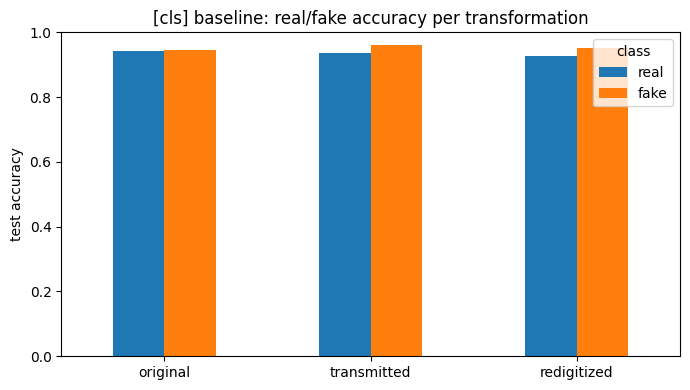


[cls] joint: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.936,0.938,0.923
fake,0.943,0.955,0.947


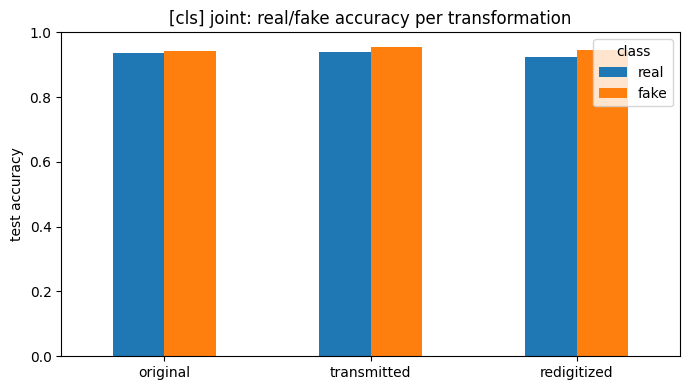


[cls] LoRA: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.940,0.944,0.924
fake,0.959,0.961,0.952


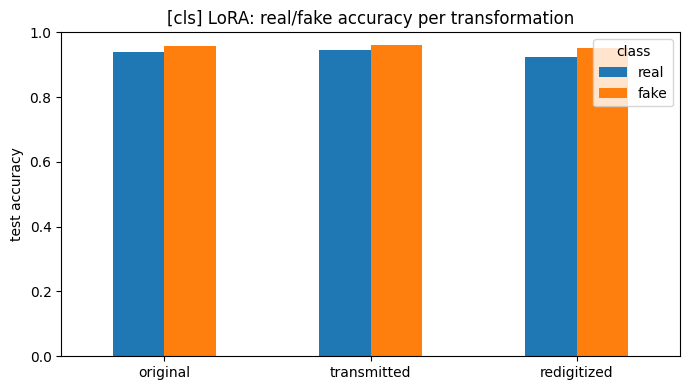

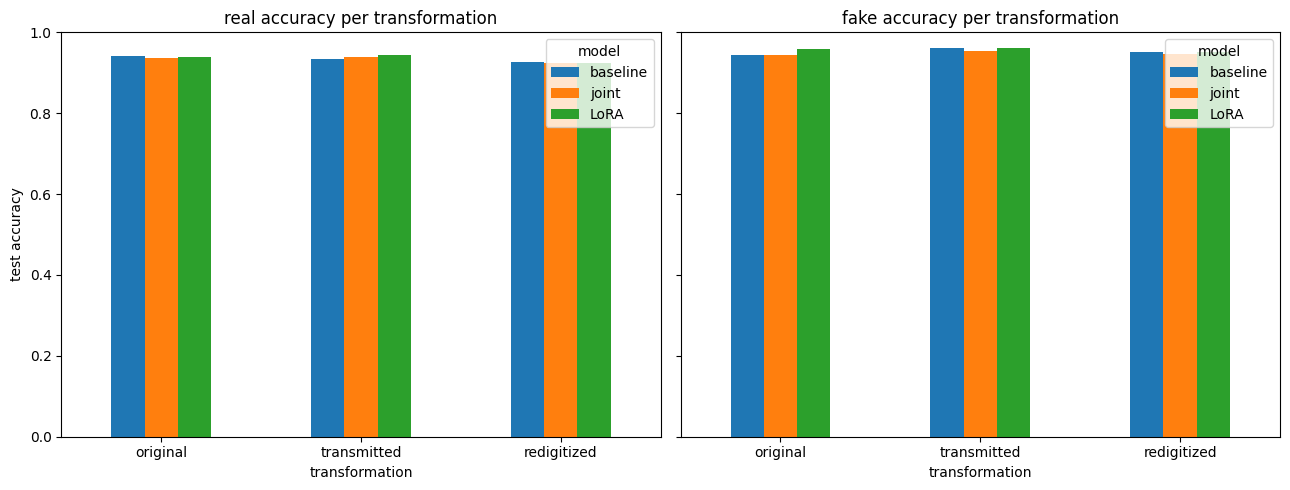


[cls] baseline: transformation accuracy per class


,original,transmitted,redigitized
real,0.756,0.826,0.877
fake,0.920,0.955,0.930


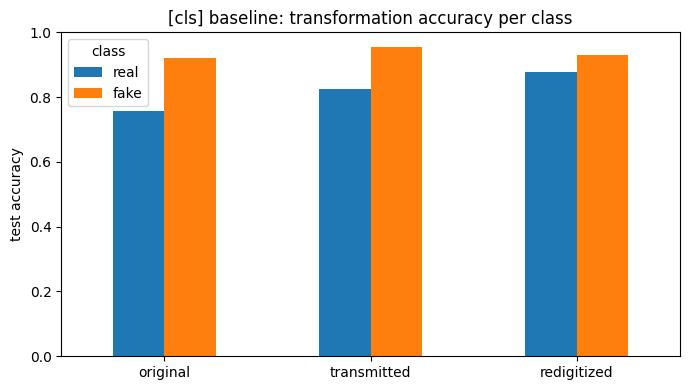


[cls] joint: transformation accuracy per class


,original,transmitted,redigitized
real,0.765,0.833,0.882
fake,0.929,0.956,0.923


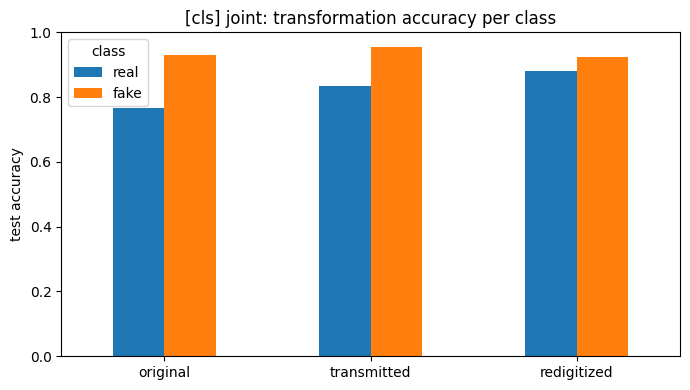


[cls] LoRA: transformation accuracy per class


,original,transmitted,redigitized
real,0.875,0.917,0.962
fake,0.980,0.985,0.978


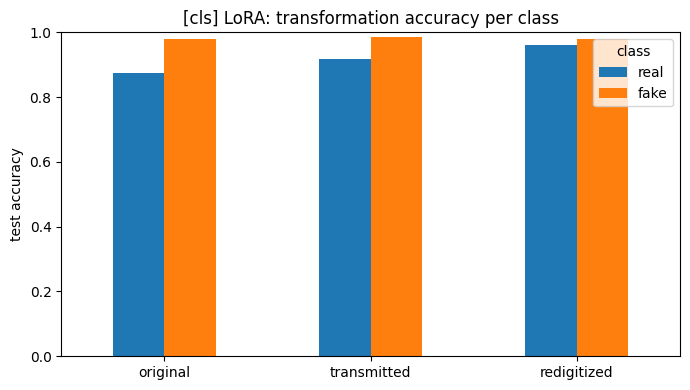


[cls] baseline: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,-0.007,-0.016
fake,0.0,0.018,0.007


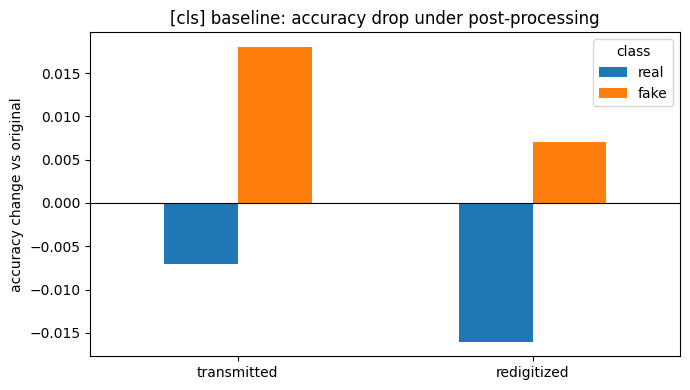


[cls] joint: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,0.002,-0.013
fake,0.0,0.012,0.004


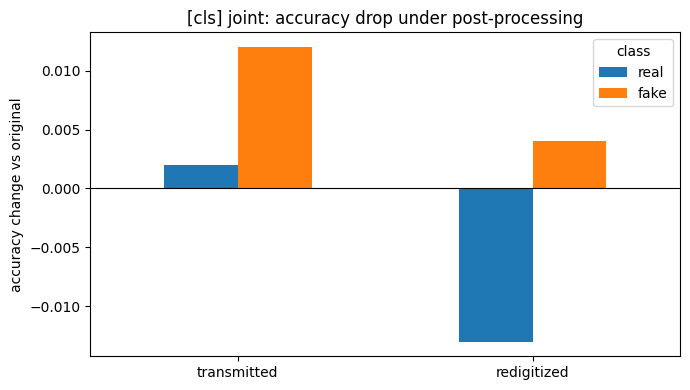


[cls] LoRA: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,0.004,-0.016
fake,0.0,0.002,-0.007


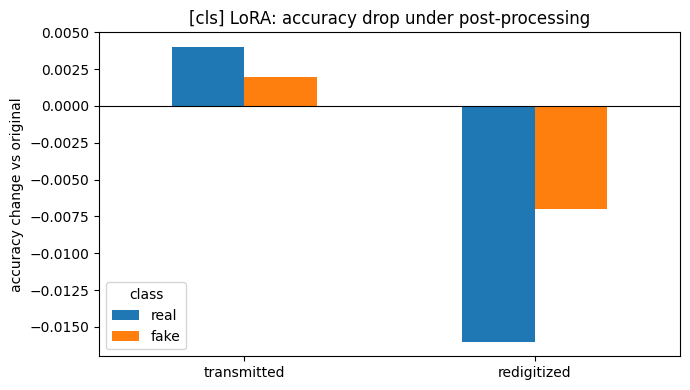

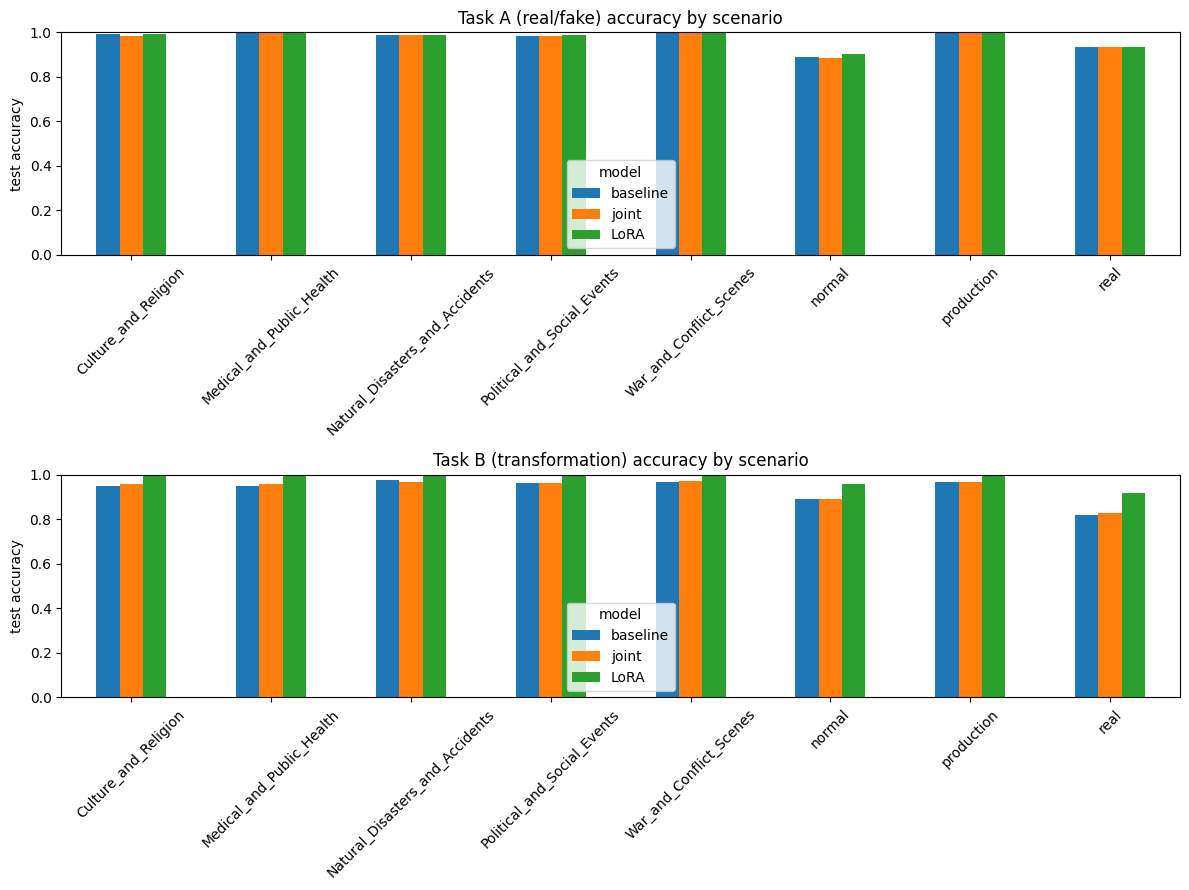

In [67]:
preds_cls = {kind: model_preds[f"{kind} (cls)"] for kind in kinds}
breakdowns_cls = run_breakdowns(preds_cls, "cls")

### Breakdown plots: CLS + FFT models
The same set of breakdown plots, for the three CLS + FFT models.


[fft] baseline: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.944,0.938,0.932
fake,0.952,0.966,0.962


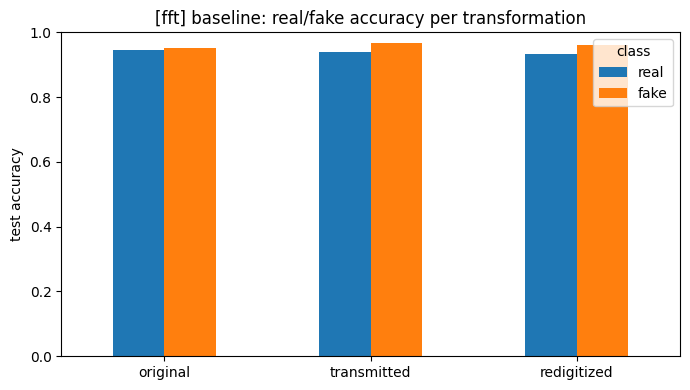


[fft] joint: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.944,0.939,0.936
fake,0.954,0.964,0.960


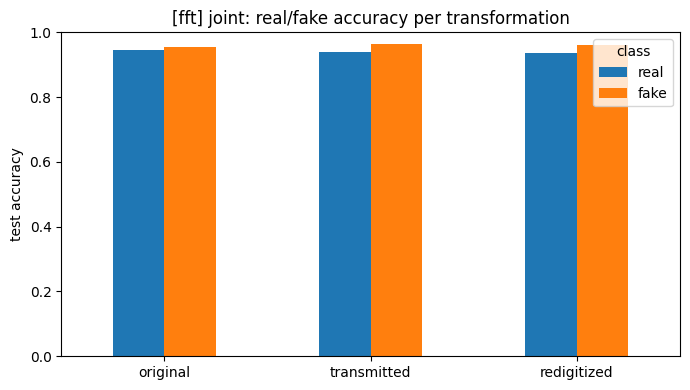


[fft] LoRA: real/fake accuracy per transformation


,original,transmitted,redigitized
real,0.954,0.952,0.944
fake,0.963,0.969,0.960


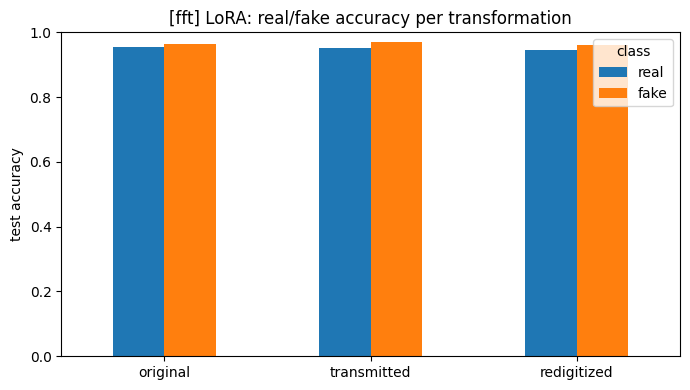

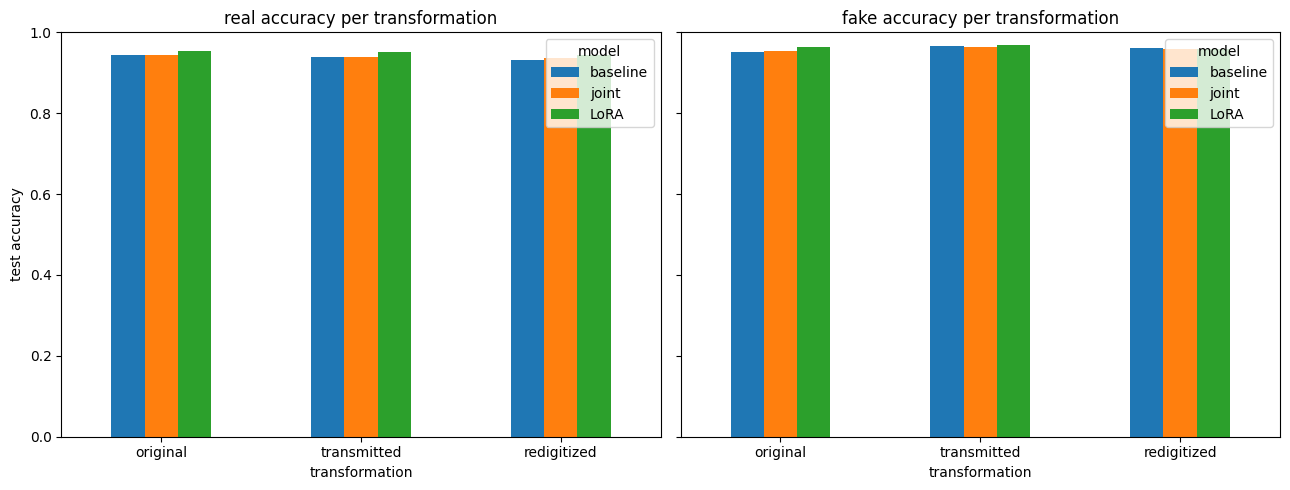


[fft] baseline: transformation accuracy per class


,original,transmitted,redigitized
real,0.787,0.828,0.915
fake,0.938,0.950,0.940


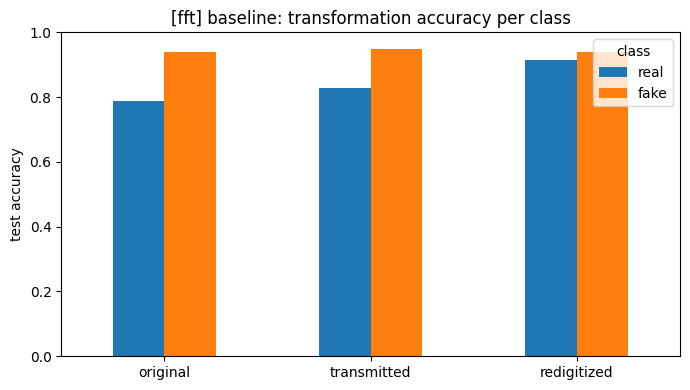


[fft] joint: transformation accuracy per class


,original,transmitted,redigitized
real,0.778,0.828,0.904
fake,0.937,0.942,0.942


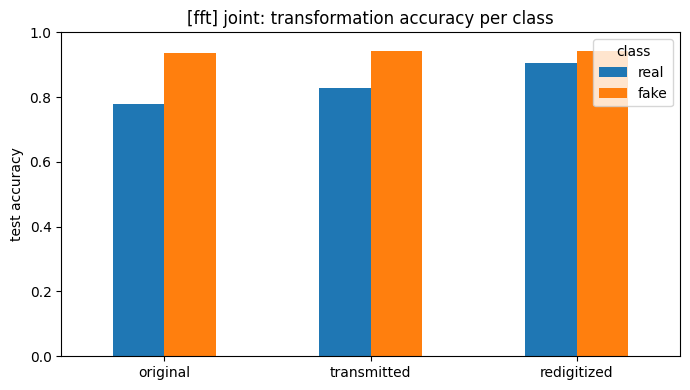


[fft] LoRA: transformation accuracy per class


,original,transmitted,redigitized
real,0.908,0.930,0.981
fake,0.989,0.988,0.989


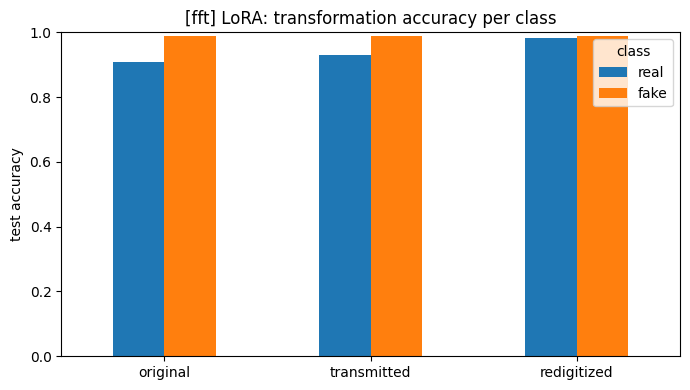


[fft] baseline: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,-0.006,-0.012
fake,0.0,0.014,0.010


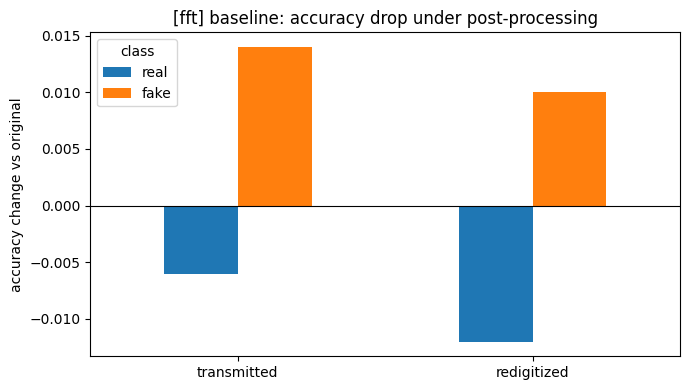


[fft] joint: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,-0.005,-0.008
fake,0.0,0.010,0.006


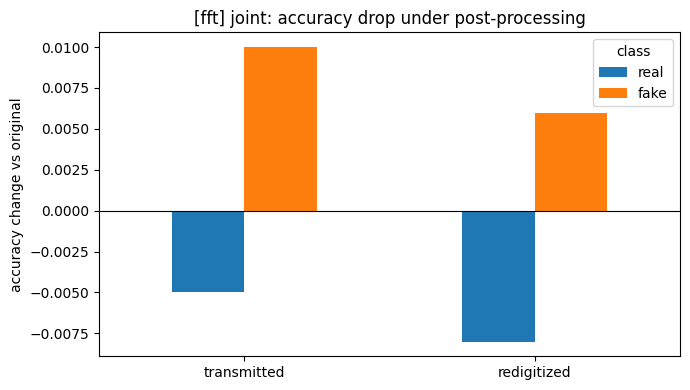


[fft] LoRA: accuracy drop under post-processing


,original,transmitted,redigitized
real,0.0,-0.002,-0.010
fake,0.0,0.006,-0.003


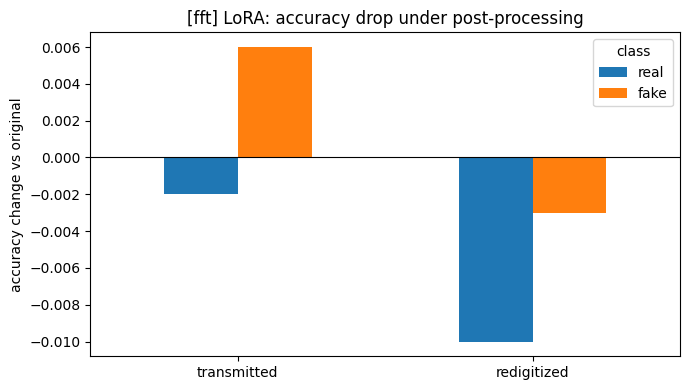

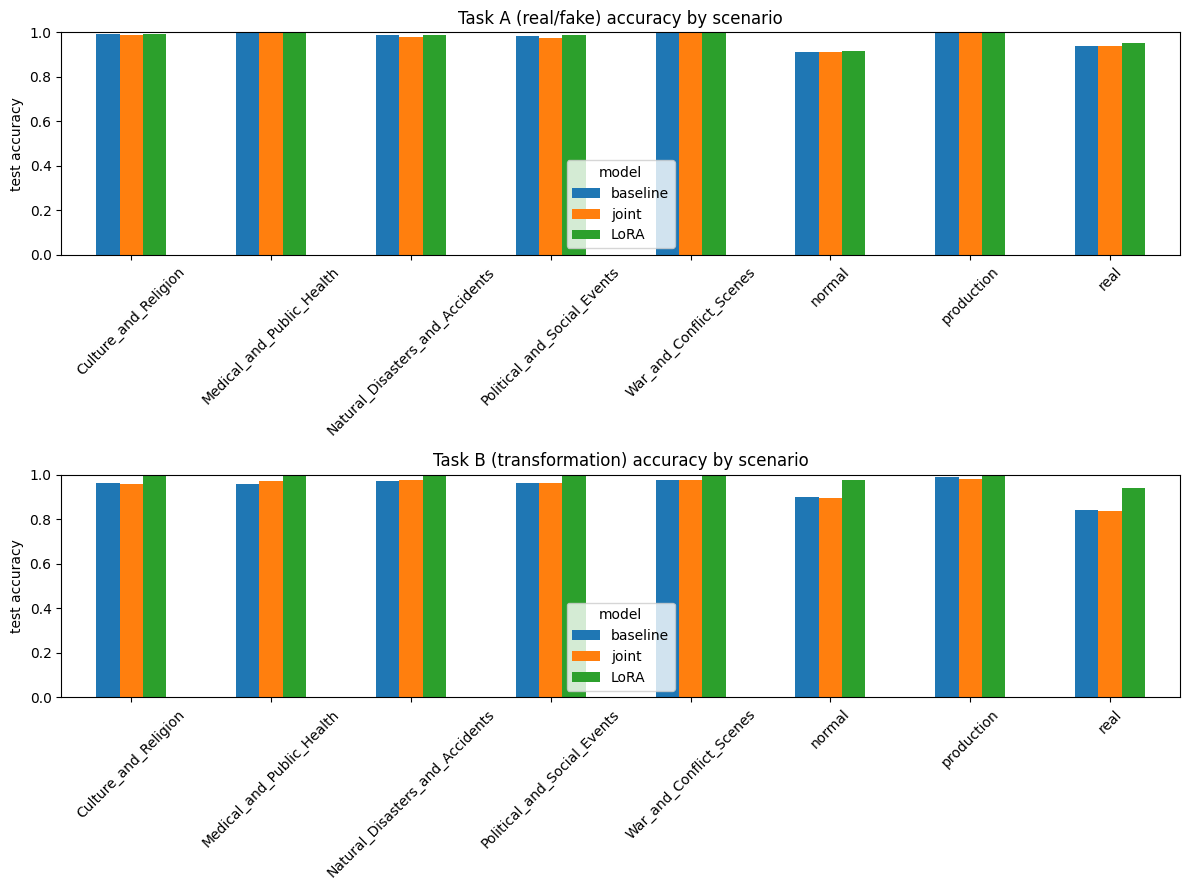

In [68]:
preds_fft = {kind: model_preds[f"{kind} (fft)"] for kind in kinds}
breakdowns_fft = run_breakdowns(preds_fft, "fft")